# Bloque 1: Instalación y Descarga del Dataset

In [1]:
!pip install ultralytics roboflow
!pip install roboflow
!pip install ultralytics roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="RtcsHZM5c4xIzxHblJOq")
project = rf.workspace("carloss-workspace-3n44o").project("vision-artificial-drive-distract")
version = project.version(1)
dataset = version.download("yolov8-obb")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 129.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Visión-Artificial-Drive-Distract-1 in yolov8-obb:: 100%|██████████| 6806/6806 [00:00<00:00, 8212.03it/s] 


# Bloque 2: Entrenamiento del Modelo Base

## YOLOv8 Nano

In [ ]:
from ultralytics import YOLO

# Cargar el modelo base preentrenado (versión Nano, la más rápida)
model = YOLO('yolov8n.pt')

# Iniciar el entrenamiento
# plots=True le dice al modelo que genere todas las gráficas posibles
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,           # Cantidad de veces que verá el dataset completo
    imgsz=640,           # Tamaño al que se redimensionarán las imágenes
    batch=16,            # Imágenes procesadas a la vez (si te da error de memoria, bájalo a 8)
    name='yolov8n_distracciones', # Nombre de la carpeta donde se guardará
    plots=True           # Generar gráficas completas de rendimiento
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Drive-Distract-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015,

## YOLOv8 Small

In [ ]:
from ultralytics import YOLO

print("=== CARGANDO YOLOv8 SMALL ===")
# Fíjate que ahora usamos la 's' (Small) en lugar de la 'n' (Nano)
model_s = YOLO('yolov8s.pt')

print("\n=== INICIANDO ENTRENAMIENTO ===")
# Entrenamos el nuevo modelo
results_s = model_s.train(
    data=f"{dataset.location}/data.yaml", # Usa el dataset de Roboflow que ya tienes
    epochs=30,                            # Mantenemos 30 épocas para poder comparar justamente
    imgsz=640,
    batch=16,                             # NOTA: Si te da error de memoria, bájalo a 8
    name='yolov8s_distracciones',         # ¡IMPORTANTE! Nombre nuevo para la carpeta
    plots=True
)

print("\n=== ¡ENTRENAMIENTO COMPLETADO! ===")

=== CARGANDO YOLOv8 SMALL ===

=== INICIANDO ENTRENAMIENTO ===
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Drive-Distract-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_distrac

## YOLOv8 Medium + Data augmentation

In [ ]:
from ultralytics import YOLO
import os

print("=== 1. CARGANDO LA BESTIA (YOLOv8 MEDIUM) ===")
# Cargamos la versión Medium, perfecta para entrenamientos largos de noche
model_heavy = YOLO('yolov8m.pt')

print("\n=== 2. CONFIGURANDO AUGMENTATION COHERENTE Y ANTI-OVERFITTING ===")
config_optima = {
    "data": f"{dataset.location}/data.yaml",
    "epochs": 100,
    "patience": 10,                 # Parada temprana si hay overfitting
    "imgsz": 640,
    "batch": 16,                    # Bájalo a 8 si Colab te da error de RAM
    "name": "yolov8m_anti_overfitting",
    "plots": True,

    # 🛡️ MEDIDAS DIRECTAS Y AGRESIVAS CONTRA OVERFITTING
    "dropout": 0.3,         # Apaga neuronas para que no memorice
    "weight_decay": 0.0005, # Freno matemático
    "erasing": 0.4,         # Tapa zonas con cuadrados negros (ej. tapa la cara para que mire la mano)

    # 🚗 DATA AUGMENTATION REALISTA PARA CONDUCCIÓN
    "hsv_h": 0.015,
    "hsv_s": 0.5,
    "hsv_v": 0.5,     # Brillo ALTO para simular cambios de luz del sol/noche

    "degrees": 10.0,
    "translate": 0.1,
    "scale": 0.4,
    "perspective": 0.0,

    "flipud": 0.0,    # No conducimos boca abajo
    "fliplr": 0.5,    # ¡ACTIVADO AL 50%! Como no distingue mano, creamos el doble de posturas gratis.

    "mosaic": 0.5,
    "mixup": 0.0,     # Sin imágenes fantasma
}

print("\n=== 3. INICIANDO ENTRENAMIENTO PESADO ===")
print("Este proceso tardará bastante. Asegúrate de que Colab no se desconecte.")
results_heavy = model_heavy.train(**config_optima)

print("\n=== ¡ENTRENAMIENTO COMPLETADO CON ÉXITO! ===")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
=== 1. CARGANDO LA BESTIA (YOLOv8 MEDIUM) ===

=== 2. CONFIGURANDO AUGMENTATION COHERENTE Y ANTI-OVERFITTING ===

=== 3. INICIANDO ENTRENAMIENTO PESADO ===
Este proceso tardará bastante. Asegúrate de que Colab no se desconecte.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Drive-Distract-1/data.yaml, degrees=10.0, deterministic

KeyboardInterrupt: 

## Yolov8 NANO - Data Augmentation

In [ ]:
from ultralytics import YOLO
import os

print("=== 1. CARGANDO EL MODELO NANO (YOLOv8n) ===")
# El modelo más ligero y rápido de la familia YOLOv8
model_nano = YOLO('yolov8n.pt')

print("\n=== 2. CONFIGURACIÓN ANTI-OVERFITTING Y AUGMENTATION ===")
config_nano_optima = {
    "data": f"{dataset.location}/data.yaml", # Asegúrate de que el bloque de Roboflow se ejecutó antes
    "epochs": 100,                  # Le damos 100 épocas, pero parará antes gracias al patience
    "patience": 7,                 # 🛡️ Parada temprana si deja de mejorar (evita memorizar)
    "imgsz": 640,
    "batch": 32,                    # ⚡ Batch más alto porque el Nano consume muy poca VRAM
    "name": "yolov8n_blindado",
    "plots": True,

    # 🛡️ PREVENCIÓN DIRECTA DE OVERFITTING
    "dropout": 0.25,        # Apaga el 25% de las neuronas en cada paso para forzar un aprendizaje global.
    "weight_decay": 0.0005, # Freno matemático que penaliza la sobre-especialización.
    "erasing": 0.4,         # Oculta partes de la imagen con cajas negras para obligarle a mirar todo el cuerpo.

    # 🚗 DATA AUGMENTATION (ADAPTADO A INTERIORES DE COCHES)
    "hsv_h": 0.015,         # Variación de tono.
    "hsv_s": 0.5,           # Variación de saturación.
    "hsv_v": 0.5,           # Variación de brillo alta (vital para simular sol, sombras y noche).

    "degrees": 10.0,        # Inclinación leve (simula baches o cámaras ligeramente torcidas).
    "translate": 0.1,       # Movimiento horizontal/vertical del conductor en el asiento.
    "scale": 0.4,           # Zoom in/out (simula si la cámara está más cerca o más lejos del volante).
    "perspective": 0.0,     # Desactivado (mantiene la geometría real del coche).

    "flipud": 0.0,          # Desactivado (nadie conduce boca abajo).
    "fliplr": 0.5,          # Activado al 50%. Como no importa qué mano usa el móvil, nos da el doble de datos.

    "mosaic": 0.5,          # Mosaico moderado para contexto.
    "mixup": 0.0,           # Desactivado (sin "fantasmas" que arruinen las posturas).
}

print("\n=== 3. INICIANDO ENTRENAMIENTO RELÁMPAGO ===")
results_nano = model_nano.train(**config_nano_optima)

print("\n=== ¡ENTRENAMIENTO COMPLETADO CON ÉXITO! ===")

=== 1. CARGANDO EL MODELO NANO (YOLOv8n) ===

=== 2. CONFIGURACIÓN ANTI-OVERFITTING Y AUGMENTATION ===

=== 3. INICIANDO ENTRENAMIENTO RELÁMPAGO ===
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Drive-Distract-1/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.25, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

In [ ]:
from ultralytics import YOLO

print("=== 1. CARGANDO NANO (LIGERO Y SIN RESTRICCIONES) ===")
model_nano_fast = YOLO('yolov8n.pt')

print("\n=== 2. CONFIGURACIÓN NATURAL (SIN ASFIXIAR AL MODELO) ===")
config_ligera = {
    "data": f"{dataset.location}/data.yaml",
    "epochs": 50,                   # 50 épocas son suficientes para el Nano
    "patience": 15,
    "imgsz": 640,
    "batch": 32,
    "name": "yolov8n_natural",
    "plots": True,

    # ❌ QUITAMOS TODA LA ARMADURA PESADA (Dropout, Erasing, Weight Decay...)

    # ✅ SOLO DEJAMOS LO BÁSICO Y EL EFECTO ESPEJO
    "fliplr": 0.5,    # El efecto espejo nos viene genial porque no distingue manos
}

print("\n=== 3. INICIANDO ENTRENAMIENTO RÁPIDO ===")
results_fast = model_nano_fast.train(**config_ligera)

print("\n=== ¡ENTRENAMIENTO COMPLETADO CON ÉXITO! ===")

=== 1. CARGANDO NANO (LIGERO Y SIN RESTRICCIONES) ===

=== 2. CONFIGURACIÓN NATURAL (SIN ASFIXIAR AL MODELO) ===

=== 3. INICIANDO ENTRENAMIENTO RÁPIDO ===
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Drive-Distract-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mo

## Yolov11 NANO overfitting

In [ ]:
from ultralytics import YOLO

print("=== 1. CARGANDO LA NUEVA GENERACIÓN: YOLO11 NANO ===")
# Descarga e inicializa el nuevo modelo YOLO11
model = YOLO('yolo11n.pt')

print("\n=== 2. CONFIGURANDO ENTRENAMIENTO ROBUSTO ===")
config_yolo11 = {
    "data": f"{dataset.location}/data.yaml",
    "epochs": 50,                # 50 épocas son perfectas para este modelo
    "patience": 15,              # Sistema de seguridad anti-overfitting
    "imgsz": 640,
    "batch": 32,                 # El Nano consume poco, procesamos 32 fotos a la vez
    "name": 'yolo11n_robusto',   # Nombre oficial de la carpeta de resultados
    "plots": True,

    # --- MEDIDAS ANTI-OVERFITTING EQUILIBRADAS ---
    "dropout": 0.15,             # Apaga un 15% de neuronas para que no memorice el fondo
    "hsv_h": 0.015, "hsv_s": 0.5, "hsv_v": 0.5, # Cambios de luz y brillo
    "degrees": 10.0, "translate": 0.1, "scale": 0.4, # Ligeros movimientos
    "fliplr": 0.5,               # Efecto espejo activado (crea el doble de ejemplos útiles)
    "mosaic": 0.5,               # Mosaicos reducidos para no confundirlo
}

results = model.train(**config_yolo11)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
=== 1. CARGANDO LA NUEVA GENERACIÓN: YOLO11 NANO ===

=== 2. CONFIGURANDO ENTRENAMIENTO ROBUSTO ===
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Drive-Distract-1/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.15, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=

## Yolov11 NANO

In [2]:
from roboflow import Roboflow
from ultralytics import YOLO
import os

print("=== PASO 1: DESCARGANDO DATASET DESDE ROBOFLOW ===")
# ATENCIÓN: He dejado tu API key, pero recuerda que es información sensible
rf = Roboflow(api_key="RtcsHZM5c4xIzxHblJOq")
project = rf.workspace("carloss-workspace-3n44o").project("vision-artificial-drive-distract")
version = project.version(1)

# Esto descarga la carpeta y guarda su ubicación en 'dataset'
dataset = version.download("yolov8-obb")

# Esta es la magia: le preguntamos a Roboflow dónde ha puesto el data.yaml
ruta_yaml = os.path.join(dataset.location, "data.yaml")
print(f"\n✅ Dataset descargado. El archivo de configuración está en: {ruta_yaml}")


print("\n=== PASO 2: ENTRENANDO YOLO11 NANO (MODO ESTRICTO) ===")
# Cargamos el modelo base
model = YOLO('yolo11n.pt')

# Entrenamos pasándole la ruta exacta que nos ha dado Roboflow
resultados = model.train(
    data=ruta_yaml,  # <--- AQUÍ ESTÁ LA SOLUCIÓN
    epochs=50,
    imgsz=432,
    batch=16,

    # Defensas contra overfitting
    patience=7,
    weight_decay=0.001,

    # Cero Data Augmentation
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, degrees=0.0, translate=0.0,
    scale=0.0, shear=0.0, perspective=0.0, flipud=0.0, fliplr=0.0,
    mosaic=0.0, mixup=0.0, copy_paste=0.0, erasing=0.0
)

print("\n✅ ¡Entrenamiento completado con éxito!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
=== PASO 1: DESCARGANDO DATASET DESDE ROBOFLOW ===
loading Roboflow workspace...
loading Roboflow project...

✅ Dataset descargado. El archivo de configuración está en: /content/Visión-Artificial-Drive-Distract-1/data.yaml

=== PASO 2: ENTRENANDO YOLO11 NANO (MODO ESTRICTO) ===
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Driv

## RT-DETR

In [3]:
!pip install ultralytics roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="RtcsHZM5c4xIzxHblJOq")
project = rf.workspace("carloss-workspace-3n44o").project("vision-artificial-drive-distract")
version = project.version(1)
dataset = version.download("yolov8") # El formato YOLOv8 es compatible con RT-DETR

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
from ultralytics import RTDETR

print("=== 1. CARGANDO EL TRANSFORMER (RT-DETR) ===")
# Descargamos el modelo RT-DETR-L
model = RTDETR('rtdetr-l.pt')

print("\n=== 2. CONFIGURACIÓN DEL ENTRENAMIENTO ESTRICTA ===")
config_rtdetr = {
    "data": f"{dataset.location}/data.yaml",
    "epochs": 40,
    "patience": 15,
    "imgsz": 640,
    "batch": 16,
    "name": 'rtdetr_distracciones',
    "plots": True,

    # 🛡️ Seguros de tamaño
    "rect": False,
    "multi_scale": False,

    # --- AUGMENTATION ---
    "hsv_h": 0.015, "hsv_s": 0.5, "hsv_v": 0.5,
    "degrees": 10.0, "translate": 0.1, "scale": 0.4,
    "fliplr": 0.5,

    # ❌ EL CULPABLE ESTÁ APAGADO: Nada de fotos gigantes de 1280x1280
    "mosaic": 0.0,
}

print("\n=== 3. INICIANDO ENTRENAMIENTO ===")
results = model.train(**config_rtdetr)

=== 1. CARGANDO EL TRANSFORMER (RT-DETR) ===

=== 2. CONFIGURACIÓN DEL ENTRENAMIENTO ESTRICTA ===

=== 3. INICIANDO ENTRENAMIENTO ===
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Drive-Distract-1/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdet

In [ ]:
import os
import glob
from IPython.display import Image, display

# Ruta a la carpeta del Transformer
runs_dir = '/content/runs/detect/rtdetr_distracciones'

print("=== BUSCANDO TODAS LAS GRÁFICAS GENERADAS ===")
graficas = glob.glob(f'{runs_dir}/*.png')

if len(graficas) == 0:
    print("No se ha encontrado ninguna gráfica. Revisa si el entrenamiento terminó correctamente.")
else:
    for imagen_path in graficas:
        nombre_archivo = os.path.basename(imagen_path)
        print(f"\n--- {nombre_archivo} ---")
        display(Image(filename=imagen_path, width=800))

In [ ]:
import shutil
from google.colab import files

runs_dir = '/content/runs/detect/rtdetr_distracciones'

# Comprimir la carpeta
shutil.make_archive('resultados_rtdetr_transformer', 'zip', runs_dir)

# Descargar al ordenador
files.download('resultados_rtdetr_transformer.zip')

print("¡Descarga iniciada! El archivo best.pt estará en la carpeta 'weights'.")

In [ ]:
import os
import glob
import zipfile
import shutil
from google.colab import files
from IPython.display import Image, display
from ultralytics import RTDETR  # Usamos el import correcto para el Transformer

print("=== PASO 1: SUBE TU ARCHIVO .ZIP CON IMÁGENES DE PRUEBA ===")
uploaded = files.upload()

if not uploaded:
    print("No se subió ningún archivo. Vuelve a ejecutar la celda.")
else:
    zip_name = list(uploaded.keys())[0]
    extract_dir = "dataset_kaggle_pruebas"

    if os.path.exists(extract_dir):
        shutil.rmtree(extract_dir)
    os.makedirs(extract_dir)

    print(f"\nDescomprimiendo {zip_name}...")
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    todas_las_imagenes = glob.glob(f'{extract_dir}/**/*.jpg', recursive=True) + \
                         glob.glob(f'{extract_dir}/**/*.jpeg', recursive=True) + \
                         glob.glob(f'{extract_dir}/**/*.png', recursive=True)

    if len(todas_las_imagenes) == 0:
        print("\n❌ ERROR: No he encontrado imágenes en el ZIP.")
    else:
        carpeta_con_imagenes = os.path.dirname(todas_las_imagenes[0])

        print("\n=== PASO 2: ANALIZANDO IMÁGENES CON RT-DETR ===")
        modelo_path = '/content/runs/detect/rtdetr_distracciones/weights/best.pt'

        if not os.path.exists(modelo_path):
            print(f"\n❌ ERROR: No se encuentra el modelo en {modelo_path}.")
        else:
            model = RTDETR(modelo_path)

            # Confianza a 0.25 para filtrar ruido
            resultados = model.predict(source=carpeta_con_imagenes, save=True, conf=0.25)

            print("\n=== PASO 3: MOSTRANDO RESULTADOS ===")
            carpetas_predict = glob.glob('/content/runs/detect/predict*')
            ultima_carpeta = max(carpetas_predict, key=os.path.getmtime)

            imagenes_procesadas = glob.glob(f'{ultima_carpeta}/**/*.jpg', recursive=True) + \
                                  glob.glob(f'{ultima_carpeta}/**/*.png', recursive=True)

            if imagenes_procesadas:
                print(f"Mostrando 3 ejemplos:")
                for img in imagenes_procesadas[:3]:
                    display(Image(filename=img, width=600))
                    print("-" * 40)

            # Descarga del ZIP con resultados
            nombre_zip_salida = 'resultados_prediccion_rtdetr'
            shutil.make_archive(nombre_zip_salida, 'zip', ultima_carpeta)
            files.download(f'{nombre_zip_salida}.zip')
            print("¡Descarga de predicciones iniciada!")

## yolov8n_v1_sin_mosaico

In [2]:
from ultralytics import YOLO

print("=== INICIANDO EXPERIMENTO V1: SIN MOSAICO ===")
# Cargar el modelo base preentrenado (versión Nano)
model = YOLO('yolov8n.pt')

# Configuración de la Versión 1
config_v1 = {
    "data": f"{dataset.location}/data.yaml",
    "epochs": 30,           # Mantenemos tus 30 épocas ganadoras
    "imgsz": 640,           # Resolución estándar
    "batch": 16,            # Tamaño de lote base
    "name": 'yolov8n_v1_sin_mosaico', # Nombre único para guardar estas gráficas
    "plots": True,          # Generar métricas

    # 🔬 EL CAMBIO QUIRÚRGICO
    "mosaic": 0.0           # Apagamos el collage. Obligamos a usar la geometría real.
}

# Iniciar el entrenamiento
results = model.train(**config_v1)

print("\n=== ¡ENTRENAMIENTO V1 COMPLETADO! ===")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
=== INICIANDO EXPERIMENTO V1: SIN MOSAICO ===
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Drive-Distract-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fract

## yolov8n_v2_adamw

In [2]:
from ultralytics import YOLO

print("=== INICIANDO EXPERIMENTO V2: OPTIMIZADOR ADAMW ===")
# Cargar el modelo base preentrenado (versión Nano)
model = YOLO('yolov8n.pt')

# Configuración de la Versión 2
config_v2 = {
    "data": f"{dataset.location}/data.yaml",
    "epochs": 30,           # Mantenemos tus 30 épocas ganadoras
    "imgsz": 640,           # Resolución estándar
    "batch": 16,            # Tamaño de lote base
    "name": 'yolov8n_v2_adamw', # Nombre único para no sobreescribir otros
    "plots": True,          # Generar métricas completas

    # 🔬 EL CAMBIO QUIRÚRGICO
    "optimizer": "AdamW"    # El motor matemático inteligente adaptativo
}

# Iniciar el entrenamiento
results = model.train(**config_v2)

print("\n=== ¡ENTRENAMIENTO V2 COMPLETADO! ===")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
=== INICIANDO EXPERIMENTO V2: OPTIMIZADOR ADAMW ===
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Drive-Distract-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript,

## yolov8n_v3_rotacion

In [5]:
from ultralytics import YOLO

print("=== INICIANDO EXPERIMENTO V3: SIMULADOR DE BACHES (ROTACIÓN) ===")
# Cargar el modelo base preentrenado (versión Nano)
model = YOLO('yolov8n.pt')

# Configuración de la Versión 3
config_v3 = {
    "data": f"{dataset.location}/data.yaml",
    "epochs": 30,           # Mantenemos tus 30 épocas ganadoras
    "imgsz": 640,           # Resolución estándar
    "batch": 16,            # Tamaño de lote base
    "name": 'yolov8n_v3_rotacion', # Nombre único para aislar los resultados
    "plots": True,          # Generar métricas completas

    # 🔬 EL CAMBIO QUIRÚRGICO
    "degrees": 15.0         # Rota las imágenes aleatoriamente entre -15 y +15 grados
}

# Iniciar el entrenamiento
results = model.train(**config_v3)

print("\n=== ¡ENTRENAMIENTO V3 COMPLETADO! ===")

=== INICIANDO EXPERIMENTO V3: SIMULADOR DE BACHES (ROTACIÓN) ===
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Drive-Distract-1/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_v3_r

## yolov8n_v4_alta_resolucion

In [9]:
from ultralytics import YOLO

print("=== INICIANDO EXPERIMENTO V4: ALTA RESOLUCIÓN ===")
# Cargar el modelo base preentrenado (versión Nano)
model = YOLO('yolov8n.pt')

# Configuración de la Versión 4
config_v4 = {
    "data": f"{dataset.location}/data.yaml",
    "epochs": 30,           # Mantenemos tus 30 épocas ganadoras
    "name": 'yolov8n_v4_alta_resolucion', # Nombre único
    "plots": True,

    # 🔬 LOS CAMBIOS QUIRÚRGICOS COMPENSADOS
    "imgsz": 800,           # Subimos la resolución (más detalle visual)
    "batch": 8              # Bajamos el lote a la mitad para no ahogar la RAM
}

# Iniciar el entrenamiento
results = model.train(**config_v4)

print("\n=== ¡ENTRENAMIENTO V4 COMPLETADO! ===")

=== INICIANDO EXPERIMENTO V4: ALTA RESOLUCIÓN ===
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Drive-Distract-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_v4_alta_resolucion, n

## yolov8n_v5_dropout

In [2]:
from ultralytics import YOLO

print("=== INICIANDO EXPERIMENTO V5: DROPOUT (ANTI-MEMORIZACIÓN) ===")
# Cargar el modelo base preentrenado (versión Nano)
model = YOLO('yolov8n.pt')

# Configuración de la Versión 5
config_v5 = {
    "data": f"{dataset.location}/data.yaml",
    "epochs": 30,           # Mantenemos tus 30 épocas ganadoras
    "imgsz": 640,           # Resolución estándar
    "batch": 16,            # Tamaño de lote base
    "name": 'yolov8n_v5_dropout', # Nombre único para aislar los resultados
    "plots": True,          # Generar métricas completas

    # 🔬 EL CAMBIO QUIRÚRGICO
    "dropout": 0.15         # Apaga un 15% de las neuronas para forzar aprendizaje profundo
}

# Iniciar el entrenamiento
results = model.train(**config_v5)

print("\n=== ¡ENTRENAMIENTO V5 COMPLETADO! ===")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
=== INICIANDO EXPERIMENTO V5: DROPOUT (ANTI-MEMORIZACIÓN) ===
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Visión-Artificial-Drive-Distract-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.15, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=t

# Bloque 3: Extracción y Visualización de Resultados

=== BUSCANDO TODAS LAS GRÁFICAS GENERADAS ===

--- BoxPR_curve.png ---


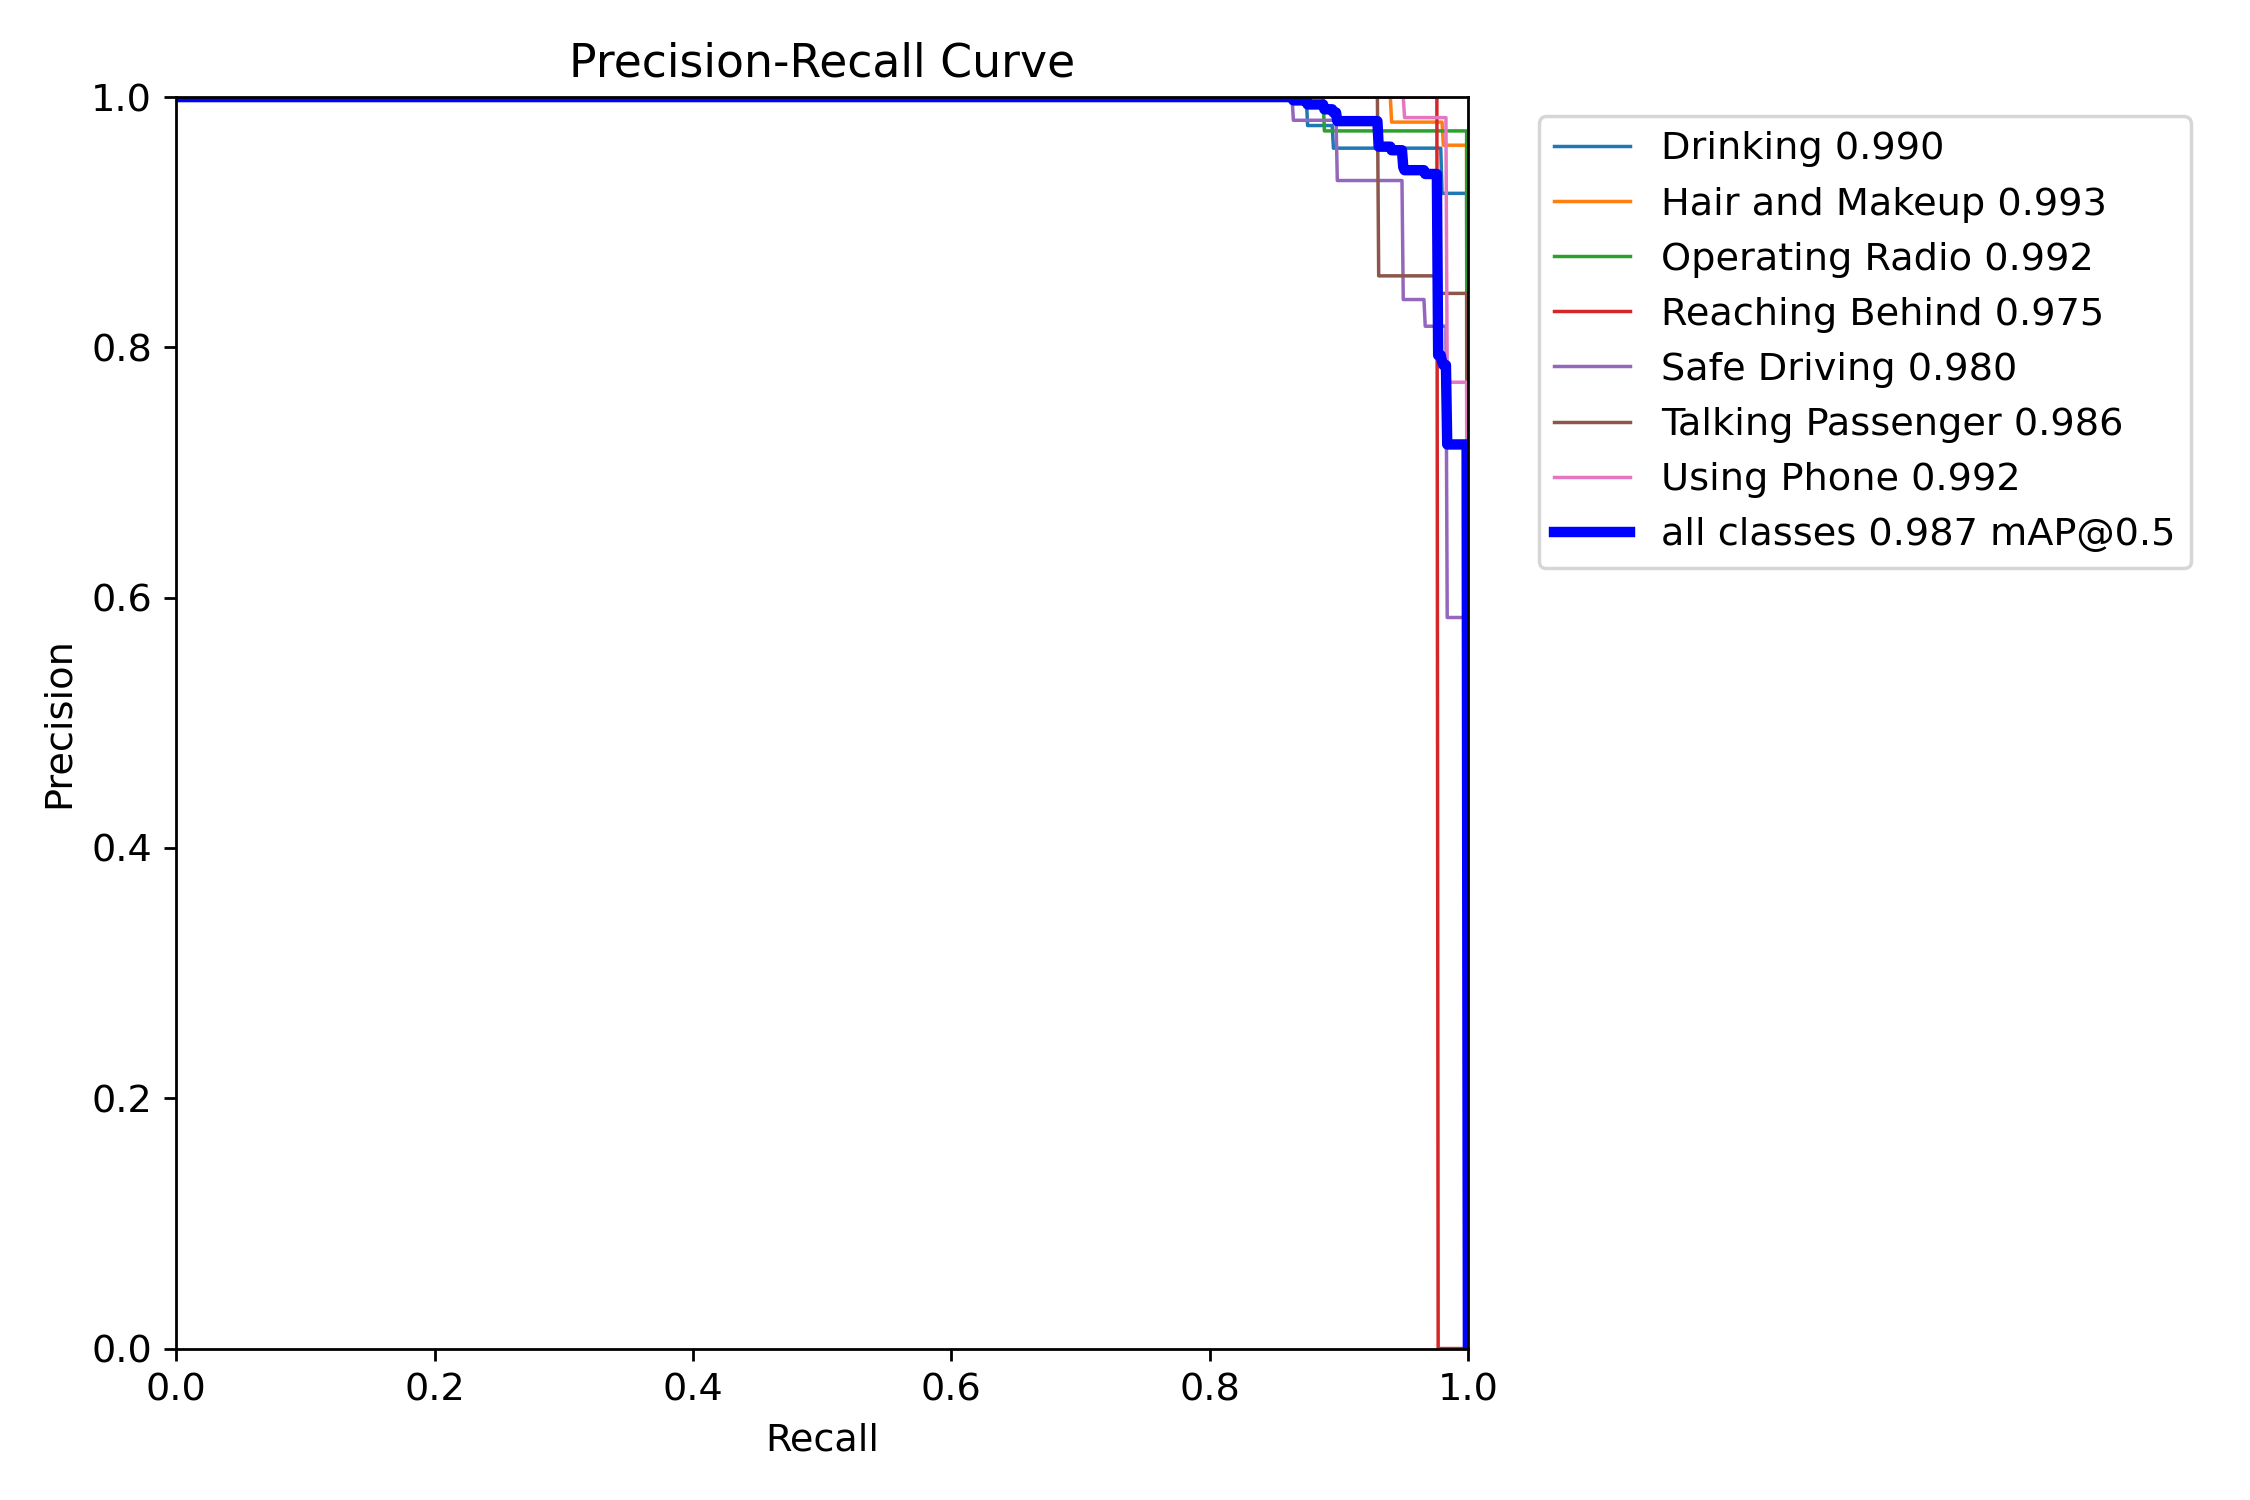


--- confusion_matrix.png ---


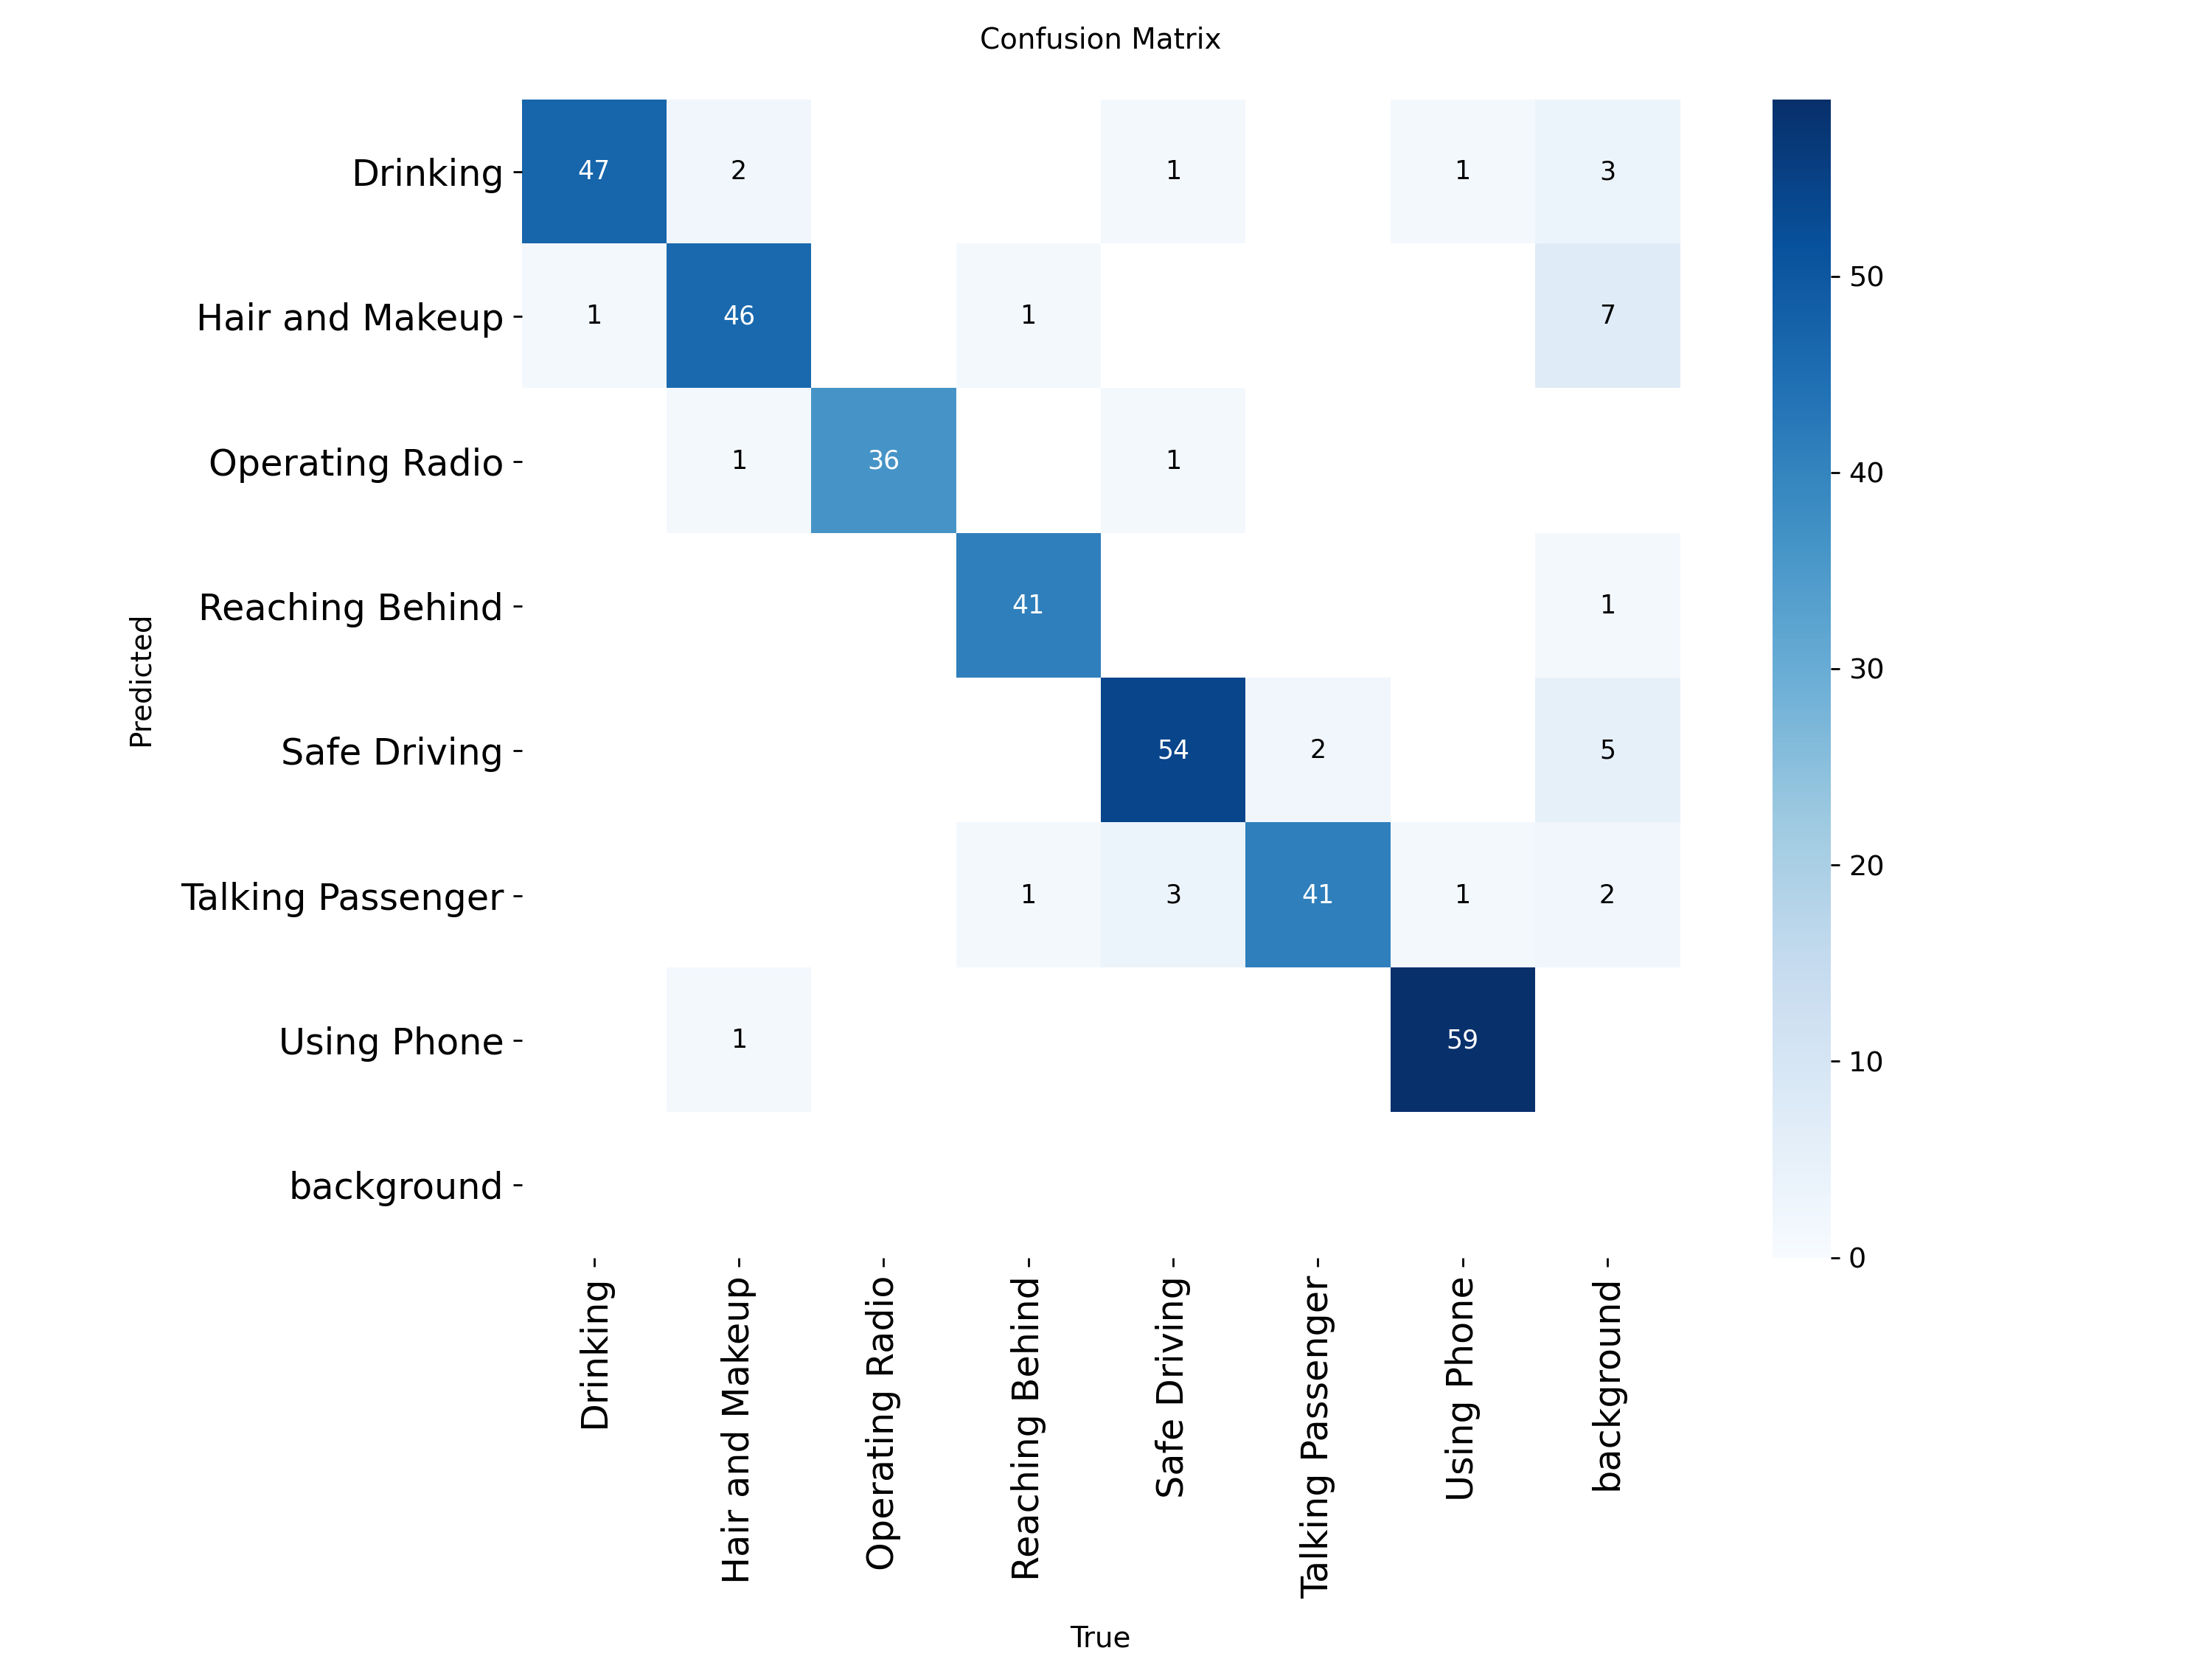


--- BoxP_curve.png ---


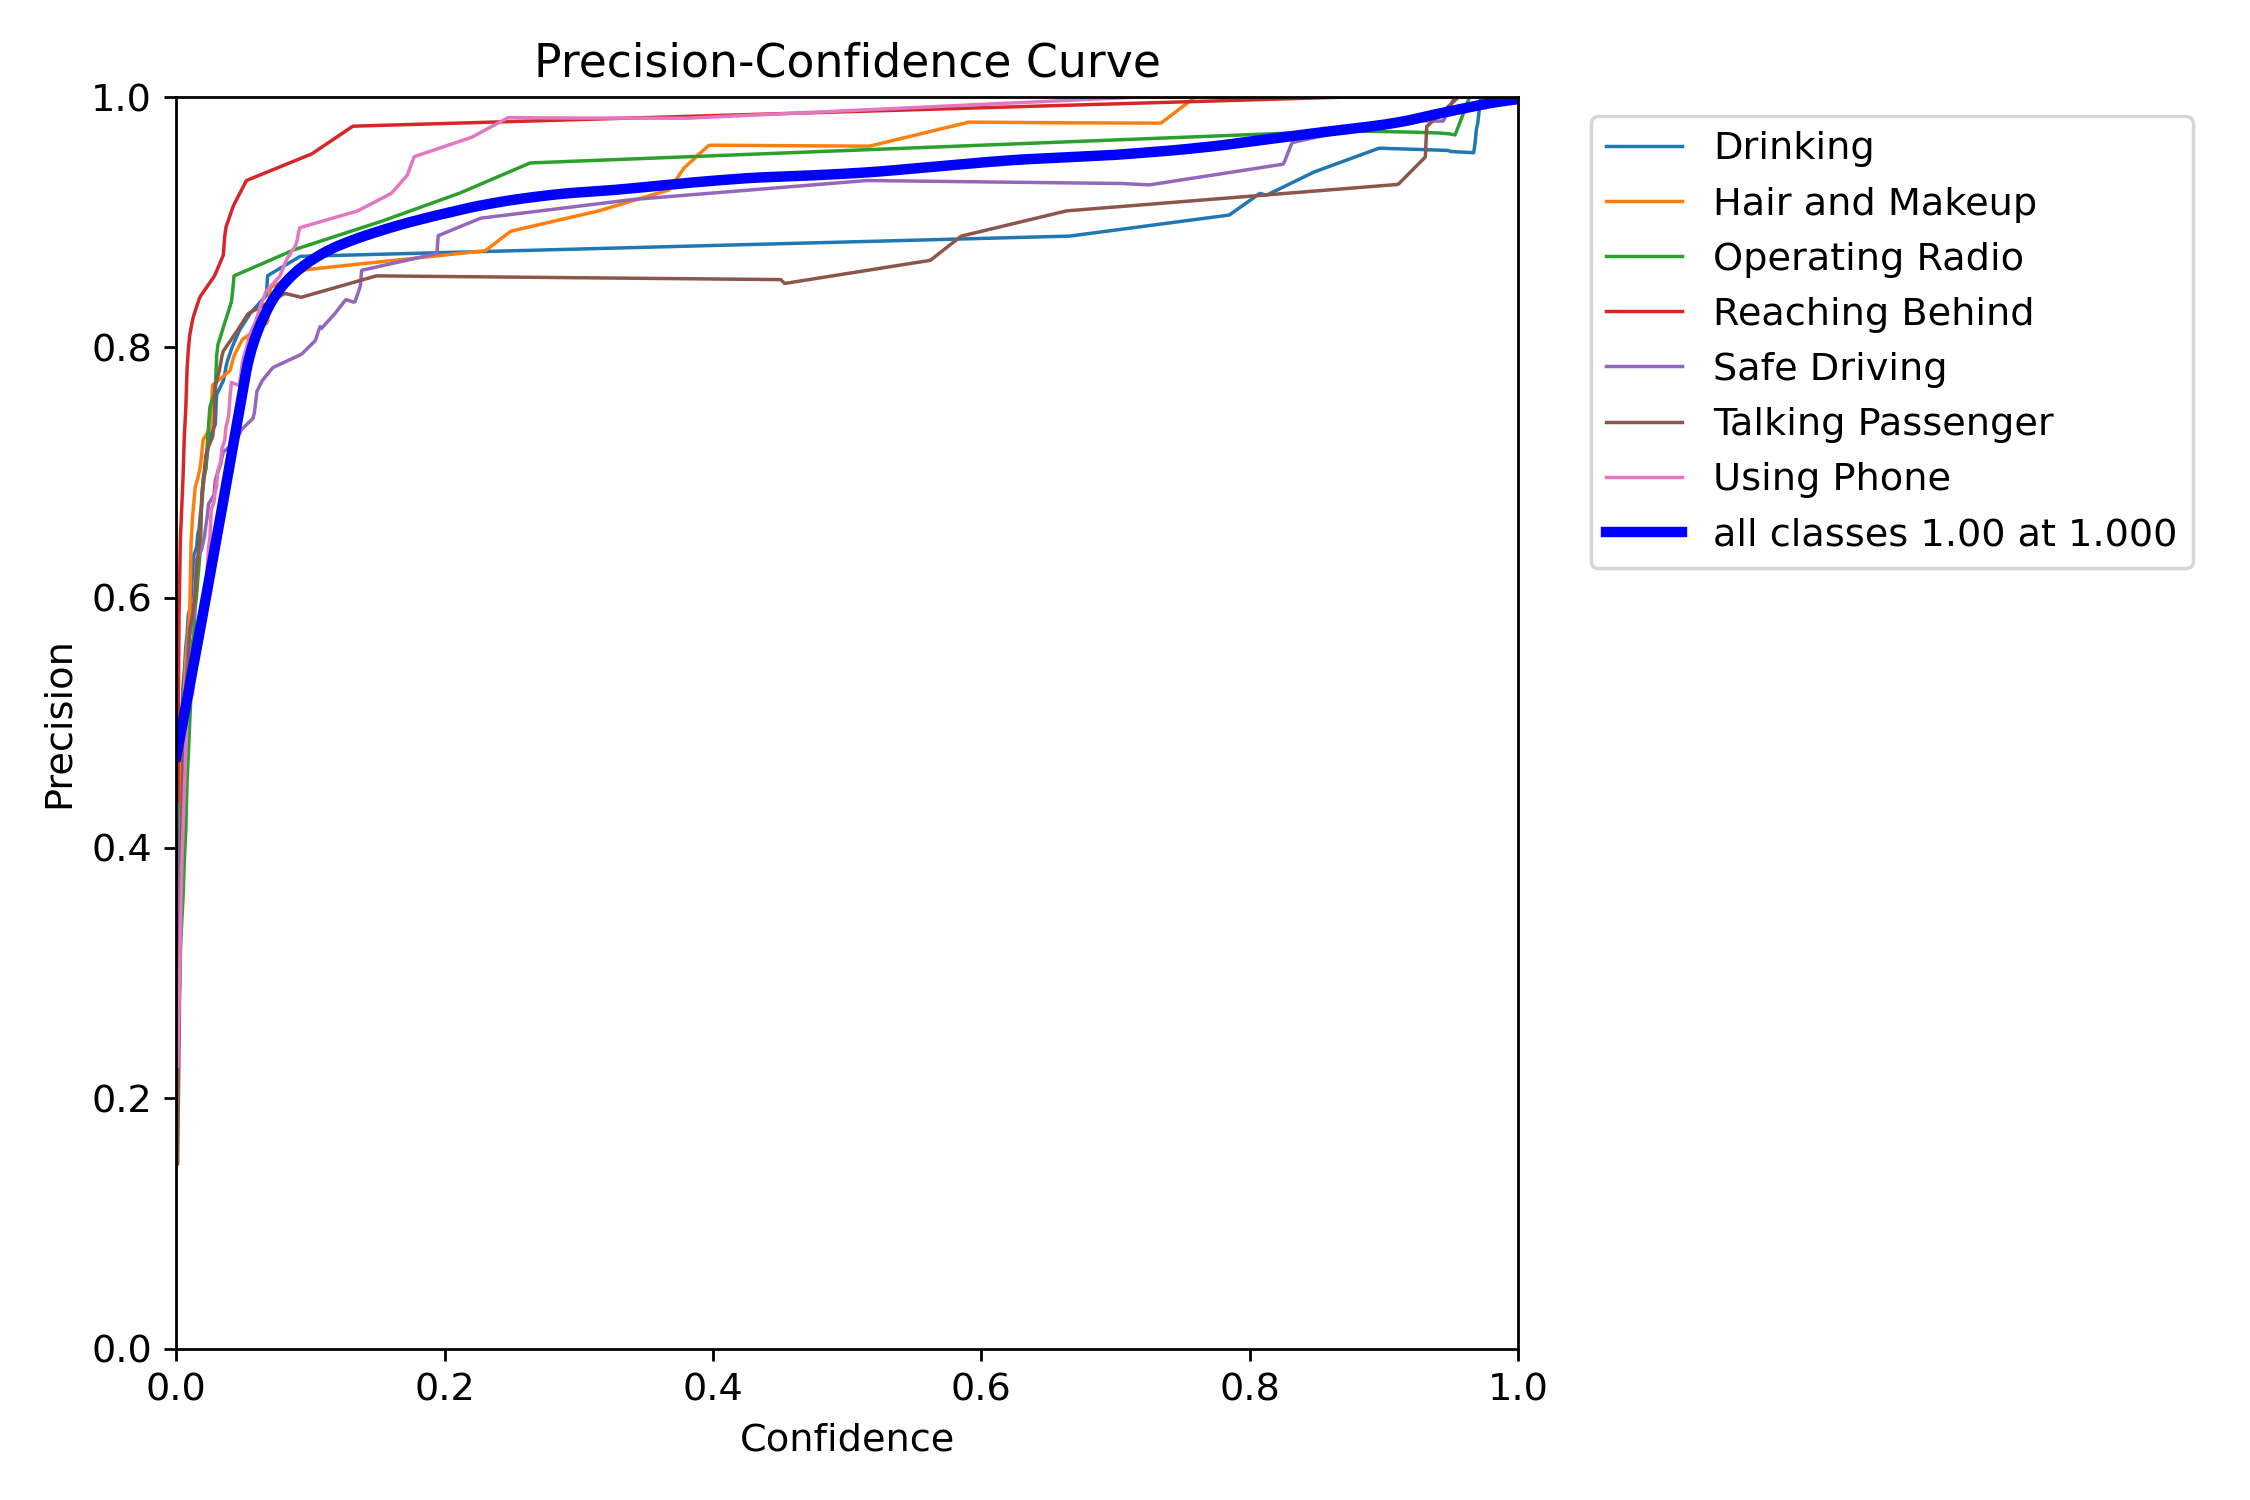


--- BoxR_curve.png ---


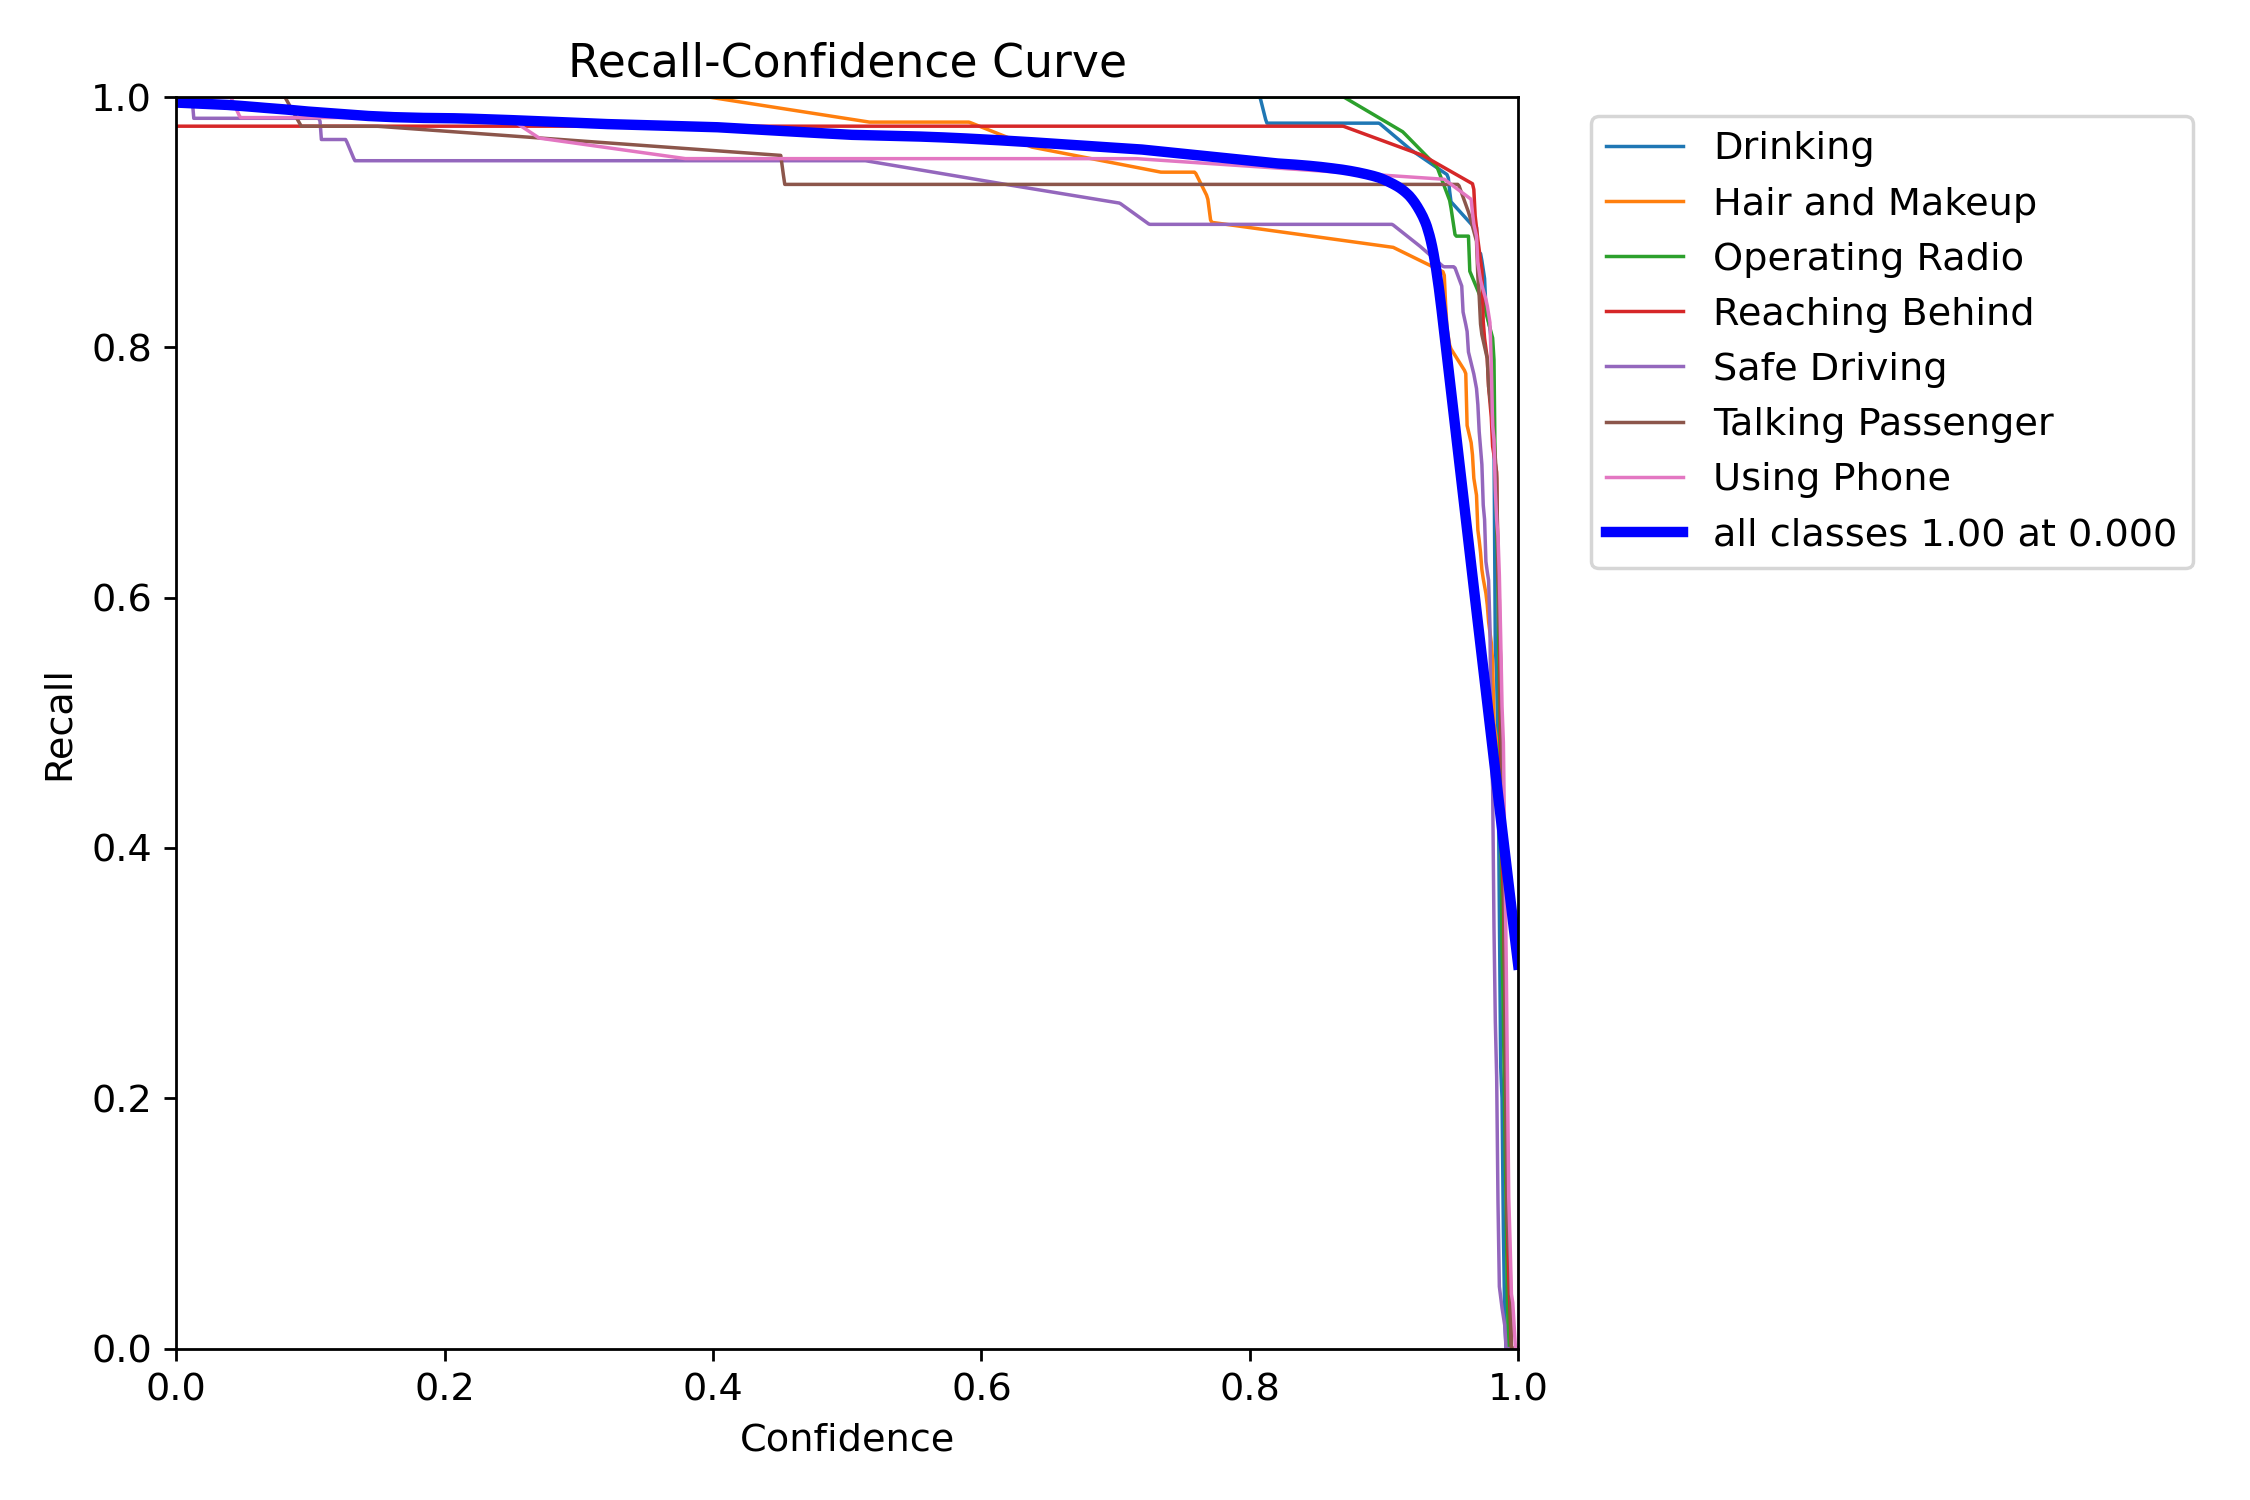


--- confusion_matrix_normalized.png ---


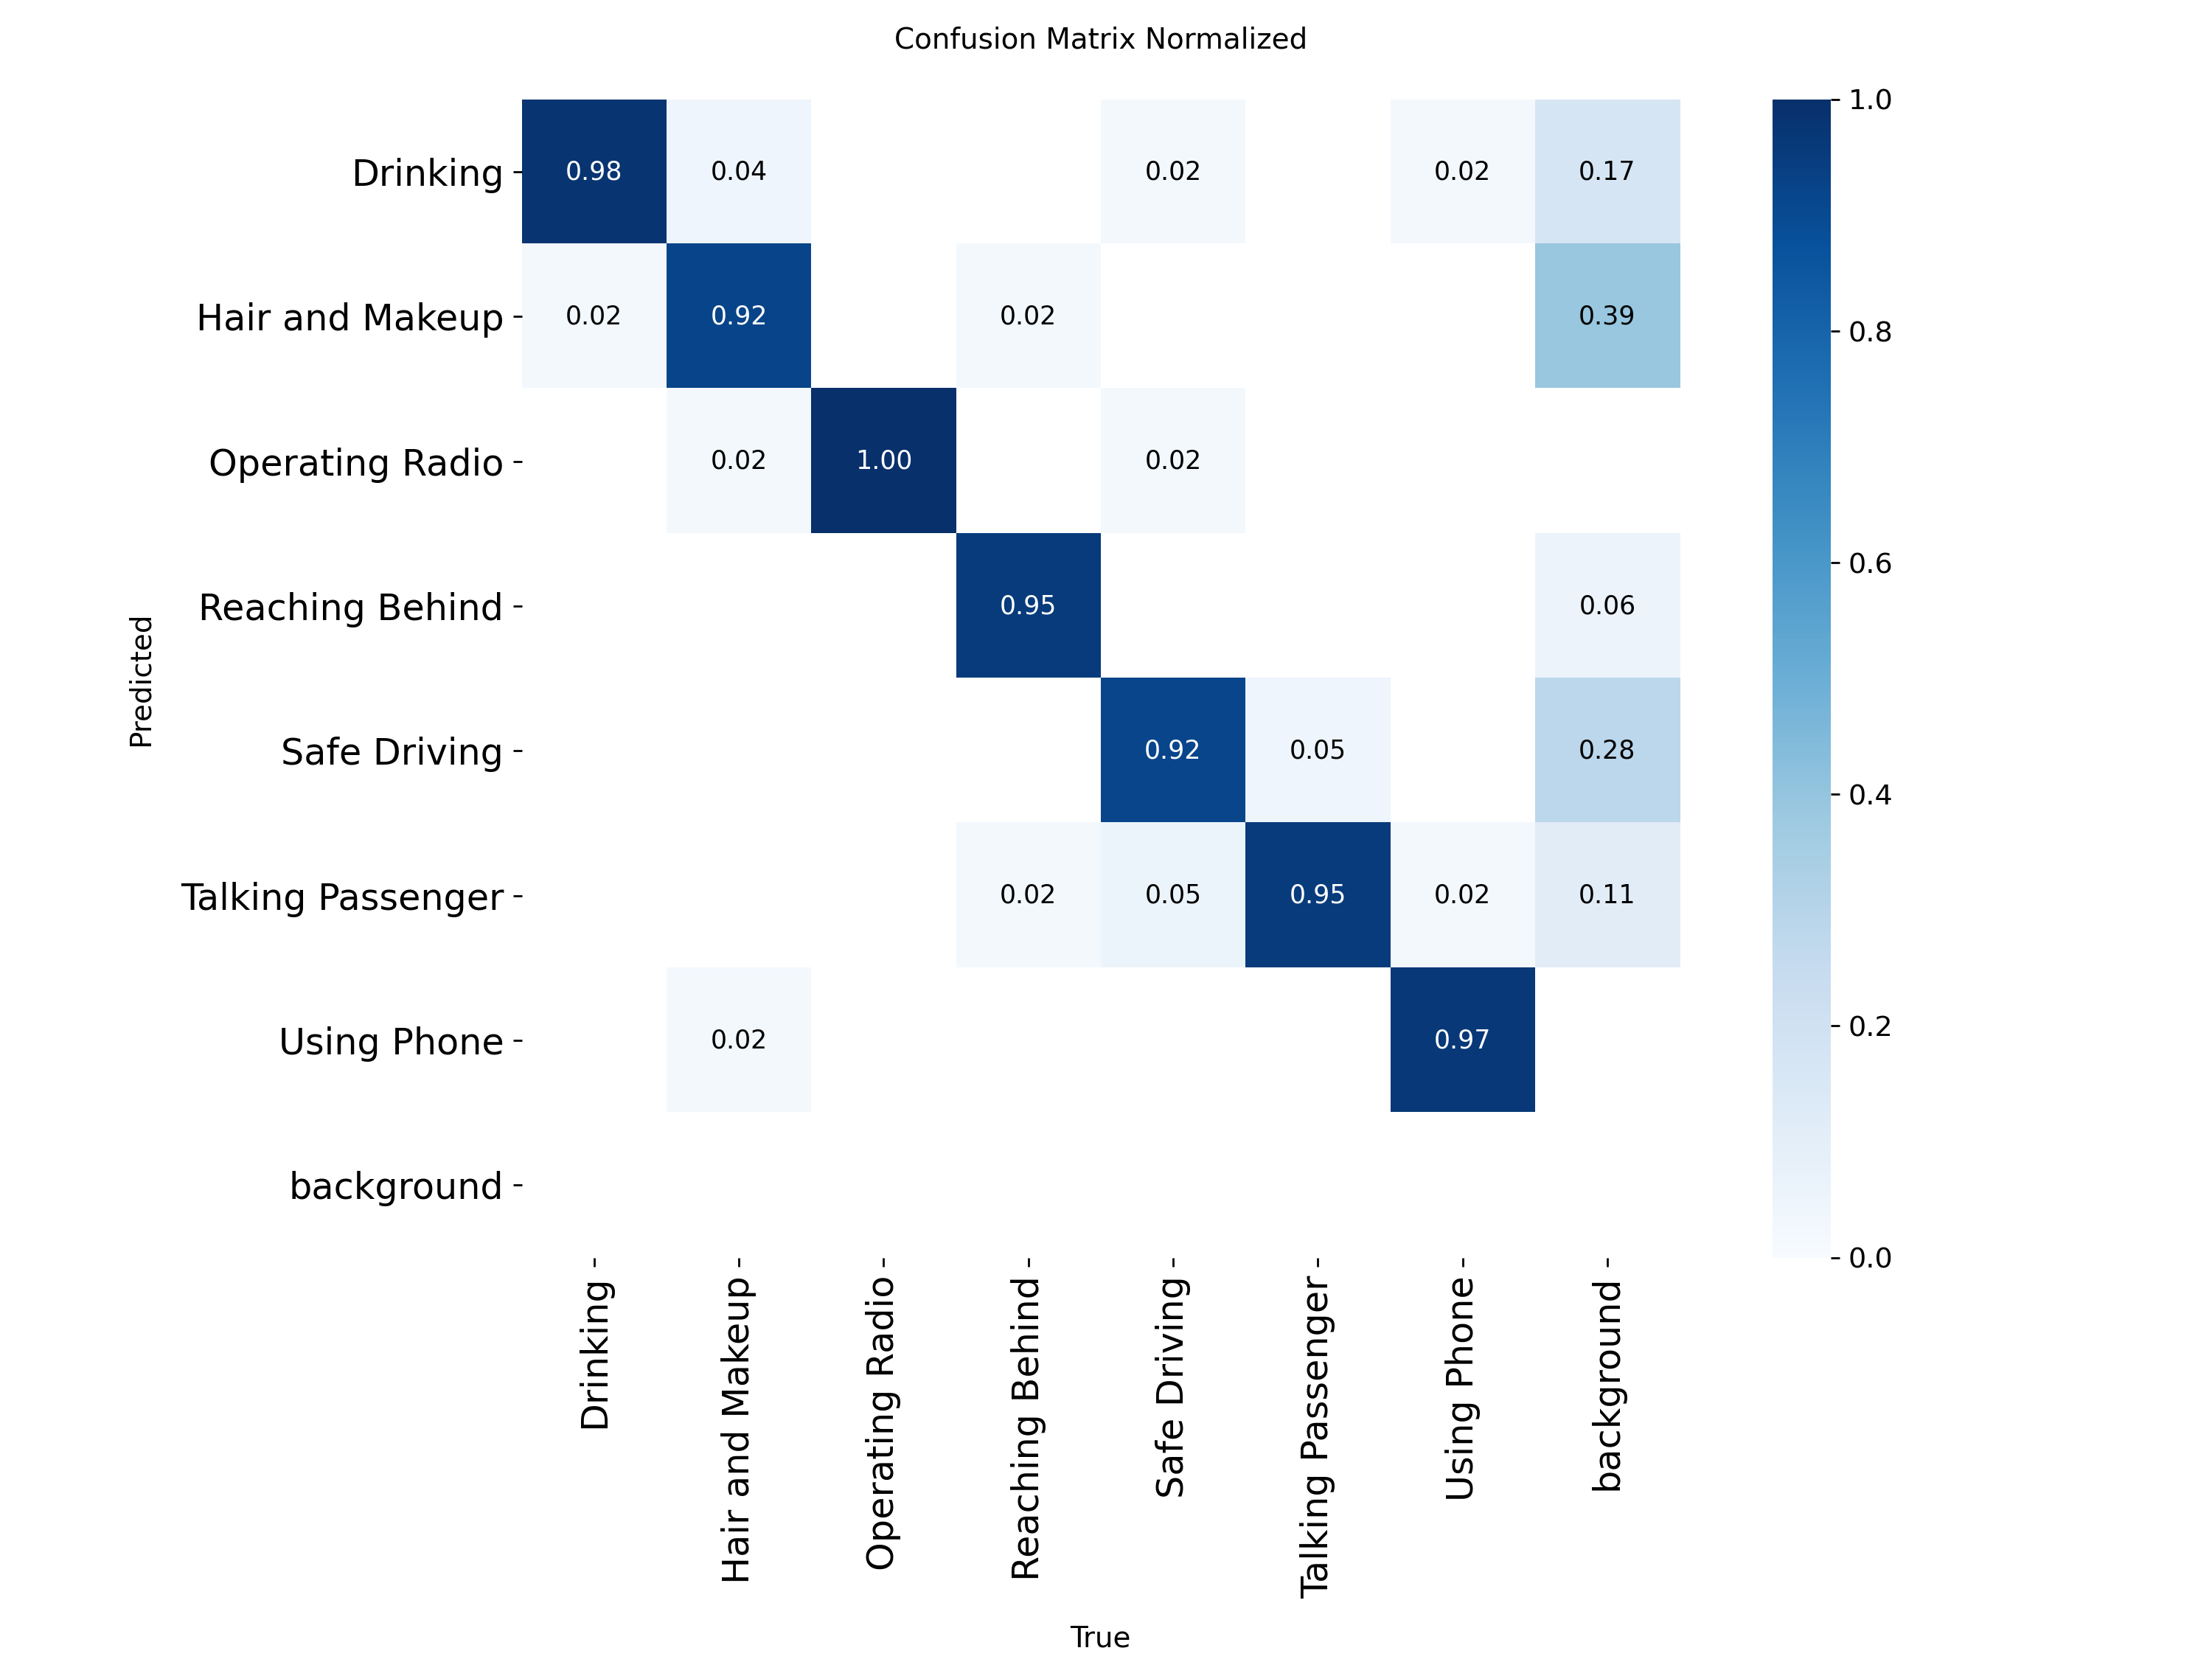


--- BoxF1_curve.png ---


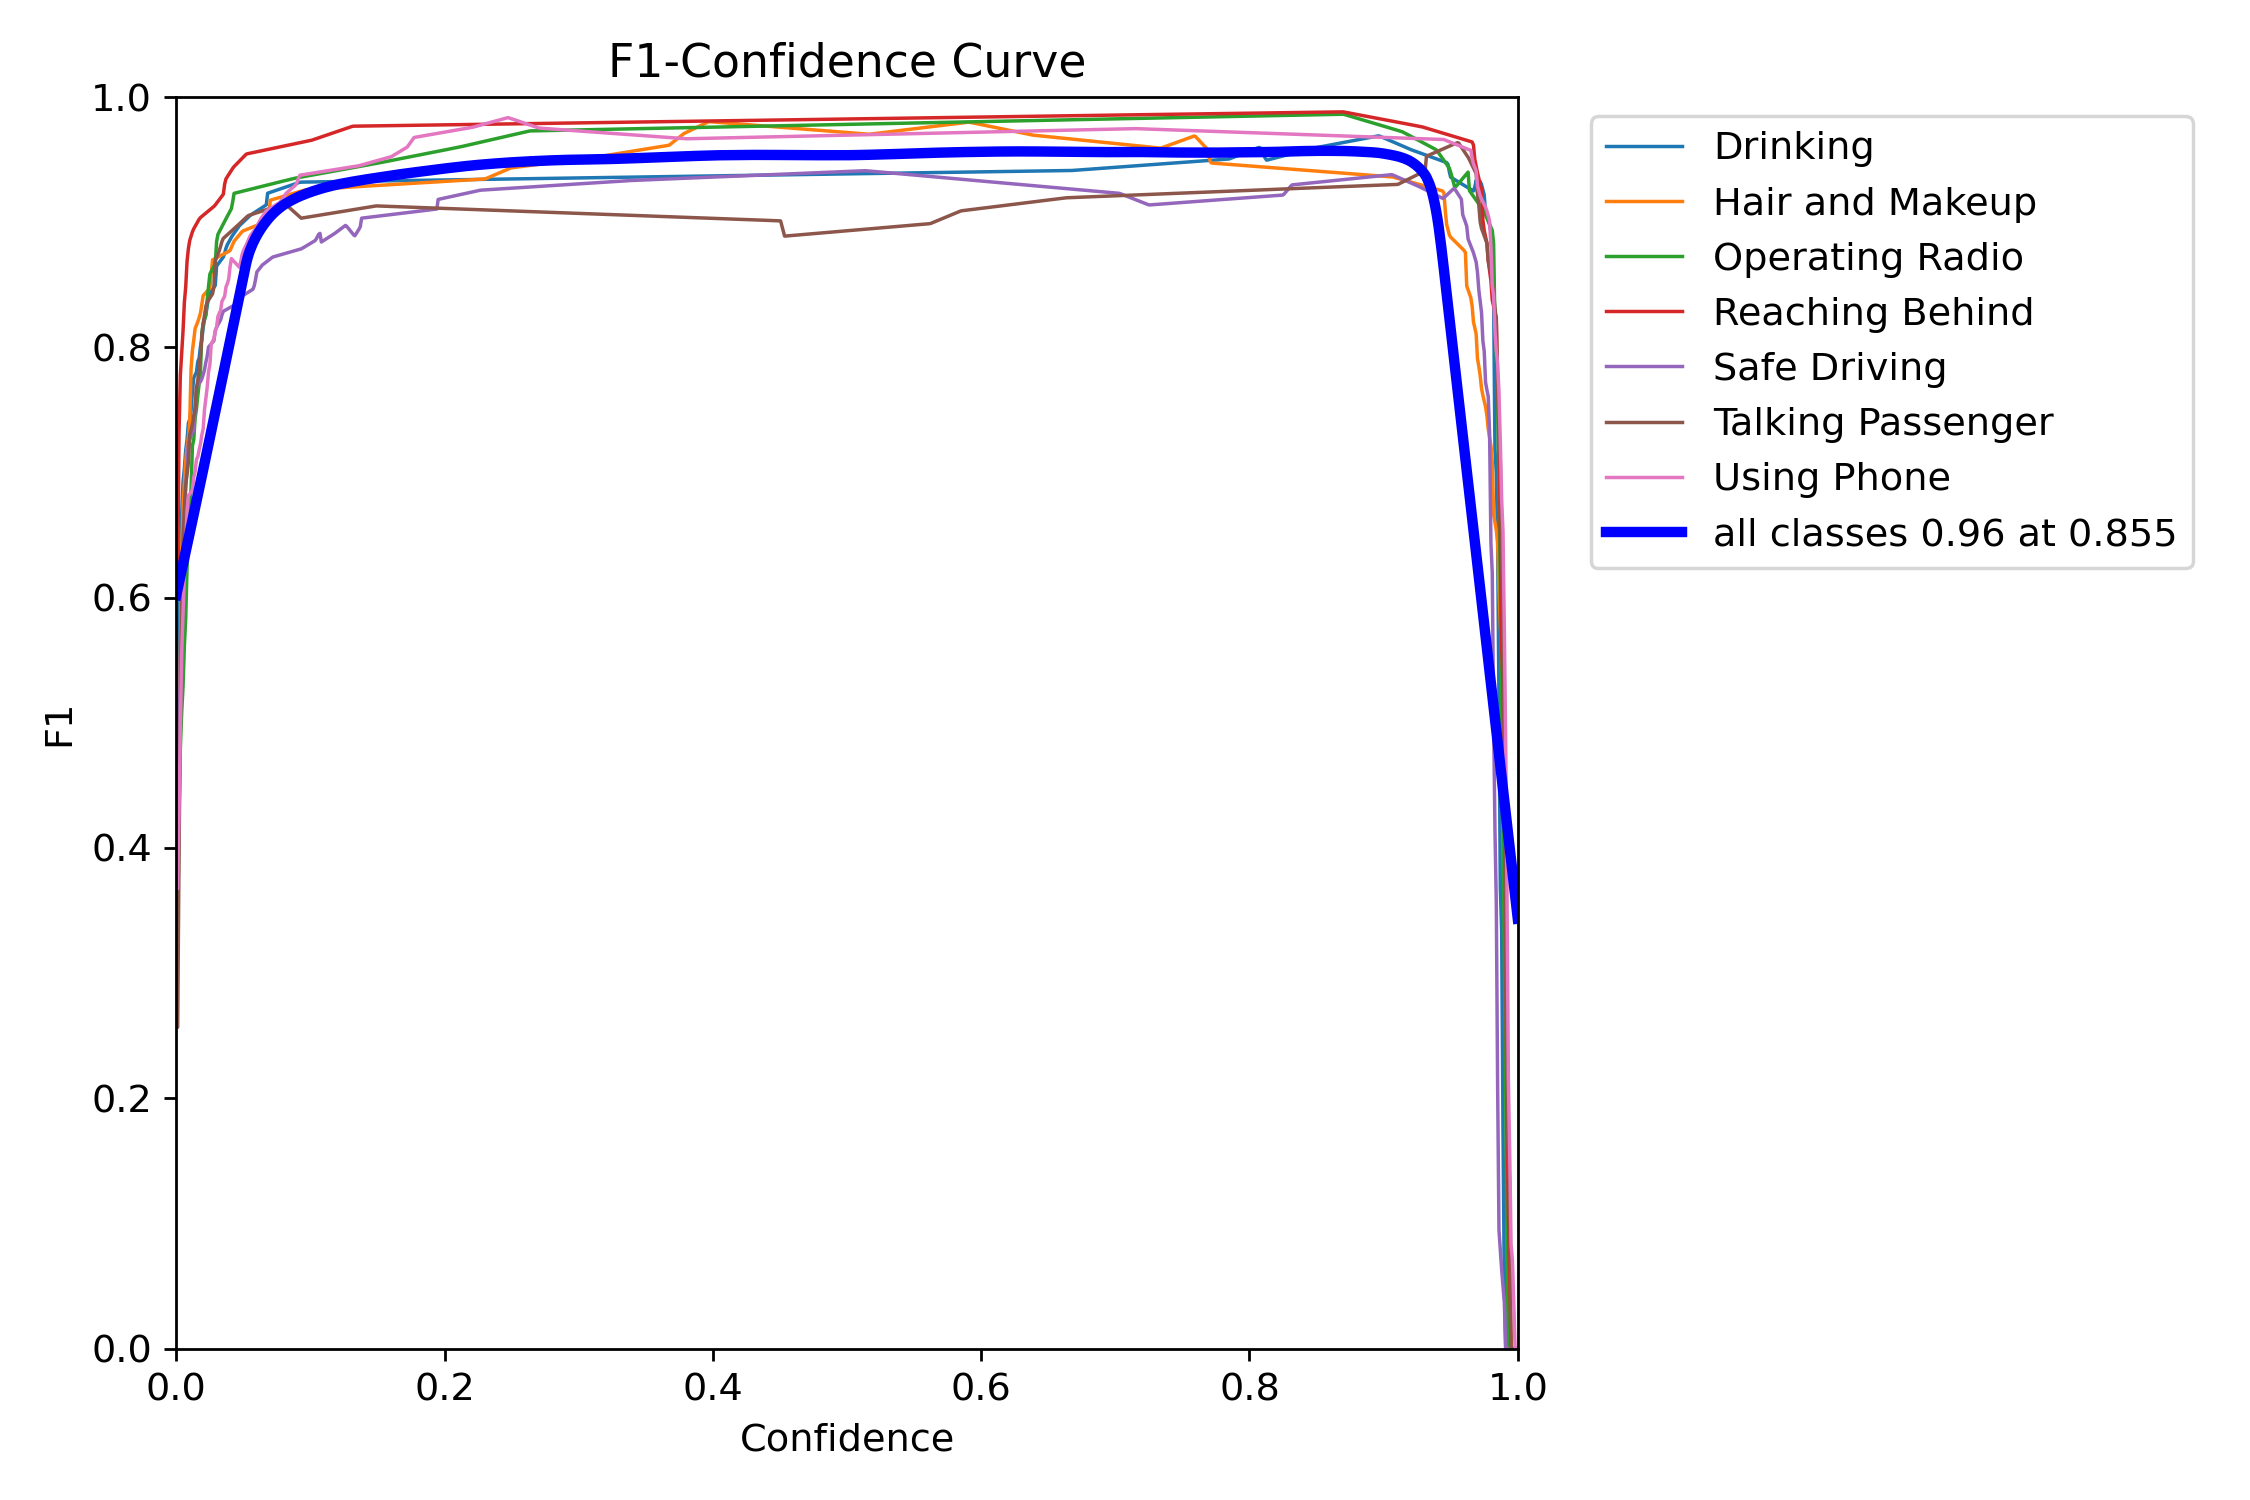


--- results.png ---


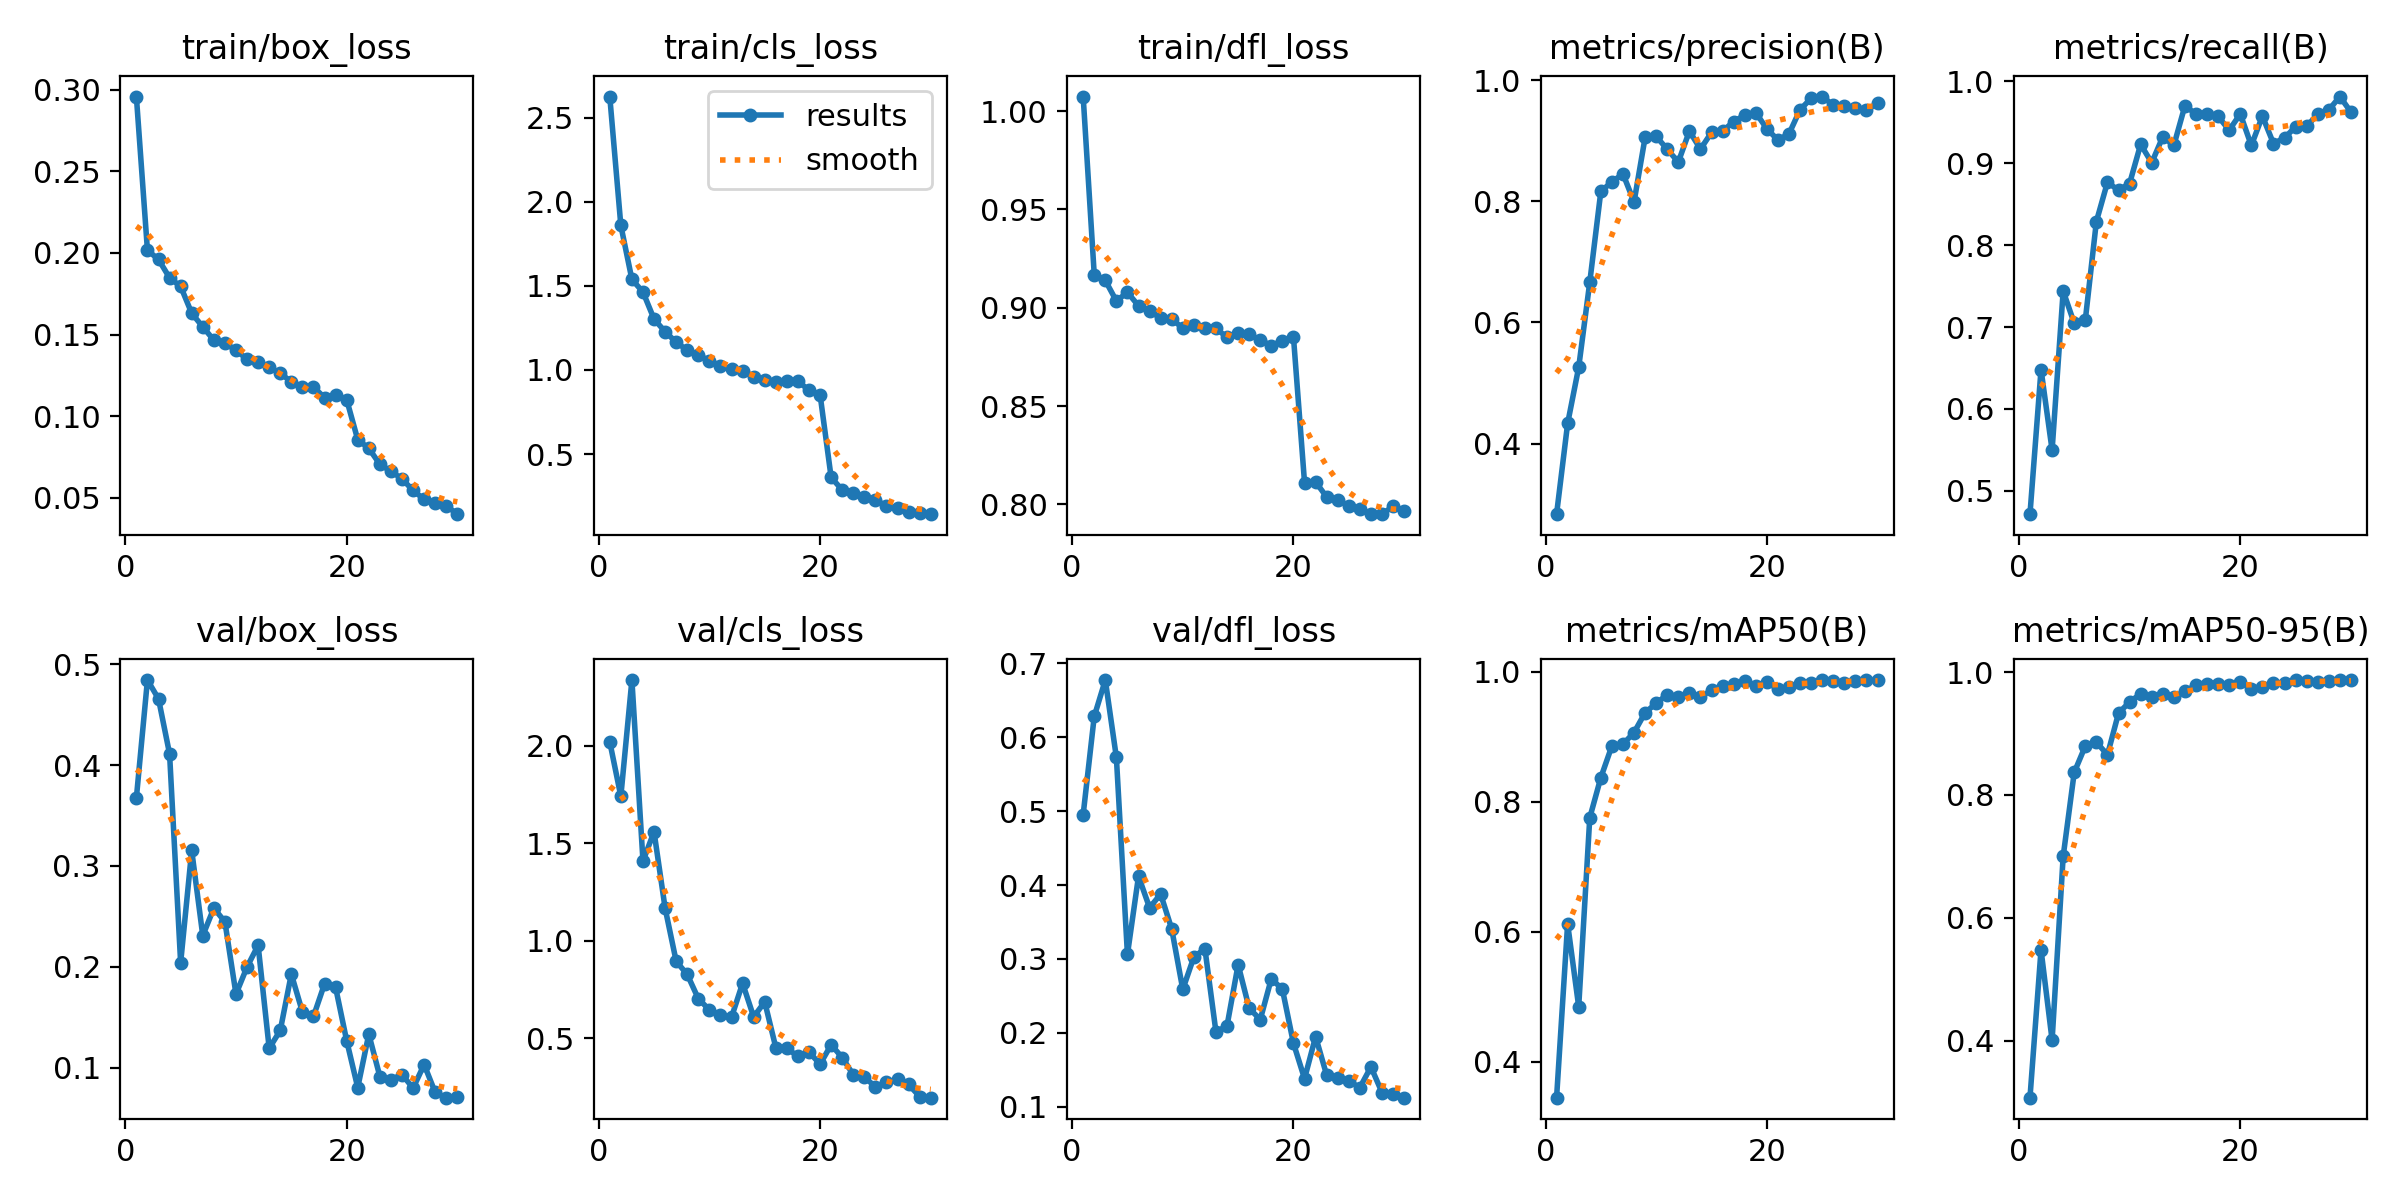

In [3]:
import os
import glob
from IPython.display import Image, display

# ACTUALIZADO: Ruta a la carpeta del nuevo modelo YOLO11
runs_dir = '/content/runs/detect/yolov8n_v5_dropout'

print("=== BUSCANDO TODAS LAS GRÁFICAS GENERADAS ===")
graficas = glob.glob(f'{runs_dir}/*.png')

if len(graficas) == 0:
    print("No se ha encontrado ninguna gráfica. Revisa si el entrenamiento terminó correctamente.")
else:
    for imagen_path in graficas:
        nombre_archivo = os.path.basename(imagen_path)
        print(f"\n--- {nombre_archivo} ---")
        display(Image(filename=imagen_path, width=800))

# Bloque 4: Guardar y descargar tus pesos

In [4]:
import shutil
from google.colab import files

# ACTUALIZADO: Ruta a la carpeta del nuevo modelo YOLO11
runs_dir = '/content/runs/detect/yolov8n_v5_dropout'

# Comprimir la carpeta de resultados
shutil.make_archive('resultados_yolov8n_v5_dropout', 'zip', runs_dir)

# Descargar a tu ordenador local
files.download('resultados_yolov8n_v5_dropout.zip')

print("¡Descarga iniciada! Tu modelo YOLO8 entrenado está dentro de la carpeta 'weights' con el nombre 'best.pt' en este zip.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

¡Descarga iniciada! Tu modelo YOLO8 entrenado está dentro de la carpeta 'weights' con el nombre 'best.pt' en este zip.


# Bolque 5: Pruebas


=== PASO 1: SUBE TU ARCHIVO .ZIP CON IMÁGENES DE PRUEBA ===


Saving ImgTest.zip to ImgTest (1).zip

Descomprimiendo ImgTest (1).zip...

✅ ¡He encontrado 153 imágenes escondidas en 'dataset_kaggle_pruebas/ImgTest'!

=== PASO 2: ANALIZANDO IMÁGENES CON YOLO11 ===

image 1/153 /content/dataset_kaggle_pruebas/ImgTest/img_1.jpg: 608x800 (no detections), 44.6ms
image 2/153 /content/dataset_kaggle_pruebas/ImgTest/img_10.jpg: 608x800 (no detections), 7.9ms
image 3/153 /content/dataset_kaggle_pruebas/ImgTest/img_100.jpg: 608x800 1 Safe Driving, 7.9ms
image 4/153 /content/dataset_kaggle_pruebas/ImgTest/img_101.jpg: 608x800 1 Safe Driving, 7.9ms
image 5/153 /content/dataset_kaggle_pruebas/ImgTest/img_103.jpg: 608x800 (no detections), 7.9ms
image 6/153 /content/dataset_kaggle_pruebas/ImgTest/img_105.jpg: 608x800 (no detections), 7.9ms
image 7/153 /content/dataset_kaggle_pruebas/ImgTest/img_106.jpg: 608x800 1 Safe Driving, 7.9ms
image 8/153 /content/dataset_kaggle_pruebas/ImgTest/img_107.jpg: 608x800 1 Safe Driving, 7.9ms
image 9/153 /content/dataset_kaggle_

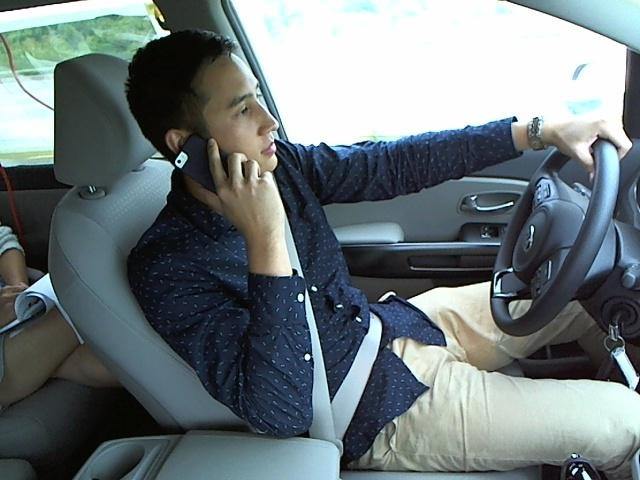

----------------------------------------


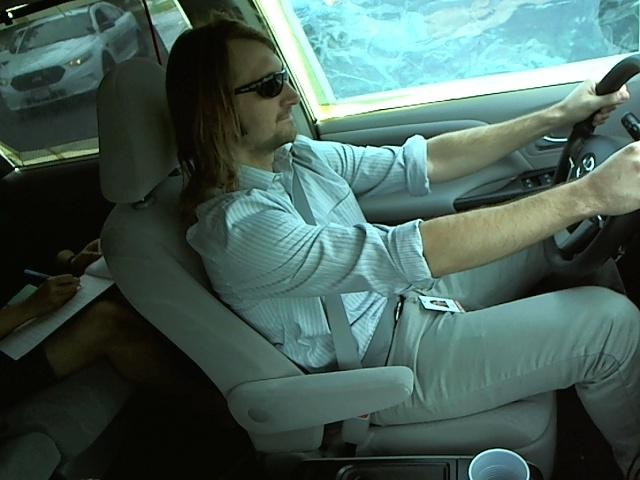

----------------------------------------


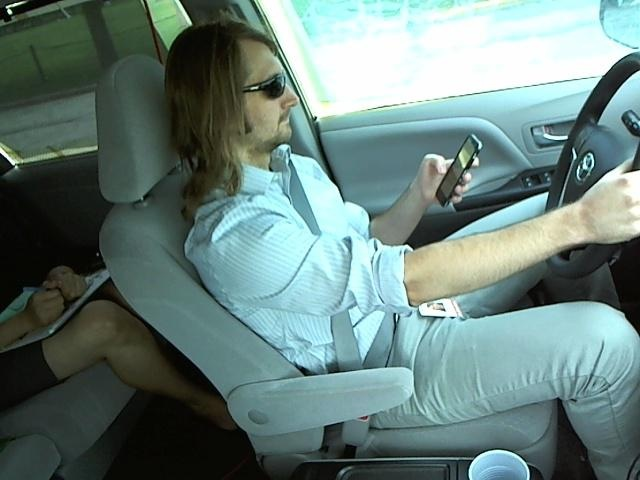

----------------------------------------

Preparando el archivo ZIP con todas tus imágenes analizadas...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

¡Descarga iniciada con éxito!


In [12]:
import os
import glob
import zipfile
import shutil
from google.colab import files
from IPython.display import Image, display
from ultralytics import YOLO

print("=== PASO 1: SUBE TU ARCHIVO .ZIP CON IMÁGENES DE PRUEBA ===")
uploaded = files.upload()

if not uploaded:
    print("No se subió ningún archivo. Vuelve a ejecutar la celda.")
else:
    zip_name = list(uploaded.keys())[0]
    extract_dir = "dataset_kaggle_pruebas"

    if os.path.exists(extract_dir):
        shutil.rmtree(extract_dir)
    os.makedirs(extract_dir)

    print(f"\nDescomprimiendo {zip_name}...")
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    todas_las_imagenes = glob.glob(f'{extract_dir}/**/*.jpg', recursive=True) + \
                         glob.glob(f'{extract_dir}/**/*.jpeg', recursive=True) + \
                         glob.glob(f'{extract_dir}/**/*.png', recursive=True)

    if len(todas_las_imagenes) == 0:
        print("\n❌ ERROR: No he encontrado ninguna imagen JPG o PNG en el ZIP.")
    else:
        carpeta_con_imagenes = os.path.dirname(todas_las_imagenes[0])
        print(f"\n✅ ¡He encontrado {len(todas_las_imagenes)} imágenes escondidas en '{carpeta_con_imagenes}'!")

        print("\n=== PASO 2: ANALIZANDO IMÁGENES CON YOLO11 ===")

        # ACTUALIZADO: Buscamos el best.pt en la carpeta nueva de yolo
        modelo_path = '/content/runs/detect/yolov8n_v5_dropout/weights/best.pt'

        if not os.path.exists(modelo_path):
            print(f"\n❌ ERROR: No se encuentra el modelo en {modelo_path}.")
        else:
            model = YOLO(modelo_path)

            # Confianza a 0.20 para resultados más limpios
            resultados = model.predict(source=carpeta_con_imagenes, save=True, conf=0.20)

            print("\n=== PASO 3: MOSTRANDO Y DESCARGANDO RESULTADOS ===")
            carpetas_predict = glob.glob('/content/runs/detect/predict*')
            ultima_carpeta = max(carpetas_predict, key=os.path.getmtime)

            imagenes_procesadas = glob.glob(f'{ultima_carpeta}/**/*.jpg', recursive=True) + \
                                  glob.glob(f'{ultima_carpeta}/**/*.png', recursive=True)

            if imagenes_procesadas:
                print(f"Mostrando 3 ejemplos en pantalla:")
                for img in imagenes_procesadas[:3]:
                    display(Image(filename=img, width=600))
                    print("-" * 40)
            else:
                print("No se pudieron generar imágenes de resultado.")

            print("\nPreparando el archivo ZIP con todas tus imágenes analizadas...")
            nombre_zip_salida = 'resultados_prediccion_kaggle_yolov8n_v5_dropout'
            shutil.make_archive(nombre_zip_salida, 'zip', ultima_carpeta)
            files.download(f'{nombre_zip_salida}.zip')
            print("¡Descarga iniciada con éxito!")

# Comparativa

In [1]:
from google.colab import files
import os
import zipfile
import shutil

print("=== 📤 SUBE AQUÍ TODOS TUS ARCHIVOS .ZIP DE RESULTADOS ===")
uploaded = files.upload()

# Crear una carpeta limpia para extraerlos
base_extract_dir = "/content/experimentos_recuperados"
if os.path.exists(base_extract_dir):
    shutil.rmtree(base_extract_dir)
os.makedirs(base_extract_dir)

# Descomprimir cada archivo en su propia subcarpeta
for zip_name in uploaded.keys():
    nombre_carpeta = zip_name.replace('.zip', '')
    ruta_destino = os.path.join(base_extract_dir, nombre_carpeta)

    print(f"Descomprimiendo {zip_name}...")
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(ruta_destino)

print("\n✅ ¡Todos los experimentos han sido cargados y preparados!")

=== 📤 SUBE AQUÍ TODOS TUS ARCHIVOS .ZIP DE RESULTADOS ===


Saving resultados_yolov8n_v5_dropout.zip to resultados_yolov8n_v5_dropout.zip
Saving resultados_yolov8n_v4_alta_resolucion.zip to resultados_yolov8n_v4_alta_resolucion.zip
Saving resultados_yolov8n_v3_rotacion.zip to resultados_yolov8n_v3_rotacion.zip
Saving resultados_yolov8n_v2_adamw.zip to resultados_yolov8n_v2_adamw.zip
Saving resultados_yolov8n_v1_sin_mosaico.zip to resultados_yolov8n_v1_sin_mosaico.zip
Saving resultados_yolo_nano.zip to resultados_yolo_nano.zip
Descomprimiendo resultados_yolov8n_v5_dropout.zip...
Descomprimiendo resultados_yolov8n_v4_alta_resolucion.zip...
Descomprimiendo resultados_yolov8n_v3_rotacion.zip...
Descomprimiendo resultados_yolov8n_v2_adamw.zip...
Descomprimiendo resultados_yolov8n_v1_sin_mosaico.zip...
Descomprimiendo resultados_yolo_nano.zip...

✅ ¡Todos los experimentos han sido cargados y preparados!


In [2]:
import pandas as pd
import glob
import os

print("=== 📊 RANKING AUTOMÁTICO DE TU ESTUDIO DE ABLACIÓN 📊 ===\n")

# Buscar los archivos results.csv en las carpetas extraídas
rutas_csv = glob.glob('/content/experimentos_recuperados/**/results.csv', recursive=True)
datos = []

for csv_path in rutas_csv:
    # Averiguar el nombre del experimento según la carpeta contenedora
    nombre_version = os.path.basename(os.path.dirname(csv_path))
    if nombre_version == "weights": # Por si se comprimió desde una subcarpeta externa
        nombre_version = os.path.basename(os.path.dirname(os.path.dirname(csv_path)))

    # Leer y limpiar datos
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # Encontrar la mejor época basándonos en mAP50-95 (la métrica más estricta de precisión)
    mejor_fila = df.loc[df['metrics/mAP50-95(B)'].idxmax()]

    datos.append({
        'Experimento': nombre_version,
        'Época Óptima': int(mejor_fila['epoch']),
        'mAP50 (%)': round(mejor_fila['metrics/mAP50(B)'] * 100, 2),
        'mAP50-95 (%)': round(mejor_fila['metrics/mAP50-95(B)'] * 100, 2),
        'Pérdida Caja (Box Loss)': round(mejor_fila['val/box_loss'], 4)
    })

if len(datos) == 0:
    print("❌ No se encontraron archivos 'results.csv'. Asegúrate de haber subido los ZIP correctos.")
else:
    # Crear DataFrame y ordenar por precisión geométrica (mAP50-95)
    df_final = pd.DataFrame(datos).sort_values(by='mAP50-95 (%)', ascending=False)
    print(df_final.to_string(index=False))

=== 📊 RANKING AUTOMÁTICO DE TU ESTUDIO DE ABLACIÓN 📊 ===

                          Experimento  Época Óptima  mAP50 (%)  mAP50-95 (%)  Pérdida Caja (Box Loss)
        resultados_yolov8n_v5_dropout            25      98.70         98.70                   0.0932
                 resultados_yolo_nano            25      98.70         98.70                   0.0932
resultados_yolov8n_v4_alta_resolucion            29      98.41         98.41                   0.1651
    resultados_yolov8n_v1_sin_mosaico            30      98.27         98.27                   0.0728
       resultados_yolov8n_v3_rotacion            30      98.16         98.16                   0.0873
          resultados_yolov8n_v2_adamw            20      18.35         18.34                   0.1337
